<a href="https://colab.research.google.com/github/rsdina/Bangladesh_13th_Election2026/blob/main/Election_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bangladesh Election 2026: Electoral, Demographic & Socioeconomic Data Analytics

This notebook performs a comprehensive data analysis of Bangladesh election data, integrating electoral, demographic, and socioeconomic indicators to uncover patterns, trends, and key insights. The project aims to provide a deeper understanding of electoral dynamics, voter behavior, and the factors influencing election outcomes in Bangladesh.

### Project Phases:

1.  **Environment Setup**: Initial configuration of the Colab environment, including Google Drive mounting, package installations, and project directory structure creation.
2.  **Data Ingestion and Cleaning**: Loading raw election and referendum data, followed by extensive cleaning, renaming, type conversion, and handling of missing values. Feature engineering is also performed to create new analytical variables.
3.  **Data Quality Reporting**: Generation of a detailed report summarizing data quality, including missing values, data types, and validation issues.
4.  **PySpark Processing (ETL)**: Leveraging Apache Spark for scalable data transformations, aggregations, window functions, and SQL analytical queries to derive advanced insights.
5.  **EDA and Visualizations - Part 1 (Matplotlib/Seaborn)**: Initial exploratory data analysis using static plots to visualize distributions and relationships, saved as PNG images.
6.  **EDA and Visualizations - Part 2 (Matplotlib/Seaborn)**: Further EDA focusing on party performance, competitiveness, and margin distributions.
7.  **Socioeconomic Analysis**: Exploration of relationships between socioeconomic indicators (poverty, literacy) and election outcomes using scatter plots.
8.  **Demographic Analysis**: Understanding voter demographics, including gender distribution and gender gap across divisions.
9.  **Statistical Analysis & Correlation**: Computation and visualization of correlation matrices and descriptive statistics for key variables.
10. **Clustering Analysis**: Application of K-Means clustering to group constituencies based on their characteristics, identifying optimal K, and interpreting cluster profiles.
11. **Referendum Analysis**: Detailed breakdown of referendum results, including vote composition and key performance indicators.
12. **Geographic Analysis with Plotly**: Interactive geographic visualizations using Plotly to explore election data across divisions, including maps, bubble charts, radar charts, and facet maps.
13. **Final Report Generation**: Compilation of all key findings and insights into a structured Markdown report.
14. **Packaging Results for Download**: Archiving all generated outputs (processed data, figures, tables, reports) into a single ZIP file for easy download.

In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install pyspark plotly folium > /dev/null 2>&1

# Create project directories
import os
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set up project structure
PROJECT_ROOT = '/content/drive/MyDrive/bangladesh-election-2026-analytics'

# Create directories
dirs = [
    PROJECT_ROOT,
    f'{PROJECT_ROOT}/data/raw',
    f'{PROJECT_ROOT}/data/processed',
    f'{PROJECT_ROOT}/outputs/figures',
    f'{PROJECT_ROOT}/outputs/tables',
    f'{PROJECT_ROOT}/outputs/reports'
]

for dir_path in dirs:
    Path(dir_path).mkdir(parents=True, exist_ok=True)
    print(f"Created: {dir_path}")

print("\n Project setup complete!")

Mounted at /content/drive
Created: /content/drive/MyDrive/bangladesh-election-2026-analytics
Created: /content/drive/MyDrive/bangladesh-election-2026-analytics/data/raw
Created: /content/drive/MyDrive/bangladesh-election-2026-analytics/data/processed
Created: /content/drive/MyDrive/bangladesh-election-2026-analytics/outputs/figures
Created: /content/drive/MyDrive/bangladesh-election-2026-analytics/outputs/tables
Created: /content/drive/MyDrive/bangladesh-election-2026-analytics/outputs/reports

 Project setup complete!


##  1. Environment Setup

This section handles the initial setup of the Colab environment. It includes:

-   **Mounting Google Drive**: To ensure persistent storage of data and outputs across sessions.
-   **Installing Required Libraries**: Essential Python packages like `pyspark`, `plotly`, `folium`, `streamlit`, `streamlit-folium`, and `pyngrok` are installed.
-   **Project Directory Structure**: Creating a standardized folder structure within Google Drive for raw data, processed data, and analytical outputs (figures, tables, reports).

In [ ]:
# Install required packages
!pip install pyspark plotly folium streamlit streamlit-folium pyngrok > /dev/null 2>&1

# Verify installations
import sys
print(f"Python version: {sys.version}")
print("\n Libraries installed successfully!")

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

 Libraries installed successfully!


## 2. Upload Files

In [ ]:
from google.colab import files

print("=" * 60)
print("UPLOAD YOUR DATA FILES")
print("=" * 60)

# Upload election.csv
print("\n Upload 'election.csv'")
uploaded_election = files.upload()

# Upload gonovote.csv
print("\n Upload 'gonovote.csv'")
uploaded_gonovote = files.upload()

# Save to Google Drive
for filename, content in uploaded_election.items():
    with open(f'{PROJECT_ROOT}/data/raw/election.csv', 'wb') as f:
        f.write(content)
    print(f" Saved: {filename}")

for filename, content in uploaded_gonovote.items():
    with open(f'{PROJECT_ROOT}/data/raw/gonovote.csv', 'wb') as f:
        f.write(content)
    print(f" Saved: {filename}")

print("\n All data files uploaded!")

UPLOAD YOUR DATA FILES

 Upload 'election.csv'


Saving election.csv to election.csv

 Upload 'gonovote.csv'


Saving gonovote.csv to gonovote.csv
 Saved: election.csv
 Saved: gonovote.csv

 All data files uploaded!


##  2. Data Ingestion and Cleaning

This section focuses on loading the raw election and referendum data, followed by a comprehensive cleaning process. Key steps include:

-   **Data Upload**: Users upload `election.csv` and `gonovote.csv` files, which are then saved to the designated raw data directory.
-   **Election Data Cleaning (`clean_election_data`)**:
    -   Loading `election.csv` while skipping initial header rows.
    -   Renaming columns for clarity and consistency.
    -   Removing non-data rows and converting `constituency_no` to integer type.
    -   Cleaning and converting various numeric columns (e.g., `poverty_rate`, `literacy_rate`, `votes`, `margin`) by removing commas and coercing to numeric types.
    -   Handling 'Postponed' election entries by setting relevant columns to `NaN`.
-   **Referendum Data Cleaning (`clean_gonovote_data`)**:
    -   Loading `gonovote.csv` and stripping whitespace from column names.
    -   Cleaning and converting numeric columns (`Percentage`, `Votes`) to appropriate numeric types.
-   **Feature Engineering (`feature_engineering`)**:
    -   Calculating `top2_votes` (winner + runner-up votes).
    -   Deriving `winner_share_top2` and `margin_pct_top2`.
    -   Calculating demographic percentages (`male_pct`, `female_pct`, `transgender_pct`) and `gender_gap`.
    -   Categorizing constituencies based on `margin_pct_top2` into `competitiveness` levels.
-   **Data Validation (`validate_election_data`)**:
    -   Performing checks for missing values, consistency (e.g., winner votes >= runner-up votes), voter demographic sums, and valid ranges for rates.
-   **Saving Processed Data**: The cleaned and enriched election and referendum dataframes are saved as `election_clean.csv` and `gonovote_clean.csv` in the processed data directory.

In [ ]:
import pandas as pd
import numpy as np
import re
import logging

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Define paths
RAW_DIR = f'{PROJECT_ROOT}/data/raw'
PROCESSED_DIR = f'{PROJECT_ROOT}/data/processed'

def clean_election_data():
    """Clean election.csv with proper header handling"""
    logger.info("Loading election data...")

    # Read with explicit header skipping (skip first 2 rows)
    df = pd.read_csv(
        f'{RAW_DIR}/election.csv',
        skiprows=2,
        encoding='utf-8'
    )

    # Column mapping
    column_mapping = {
        '#': 'constituency_no',
        'Division': 'division',
        'Name': 'constituency_name',
        'Poverty rate (HCR)': 'poverty_rate',
        'Literacy rate (%)': 'literacy_rate',
        'Candidate': 'winner_candidate',
        'Party': 'winner_party',
        'Votes': 'winner_votes',
        'Candidate.1': 'runner_candidate',
        'Party.1': 'runner_party',
        'Votes.1': 'runner_votes',
        'Margin': 'margin',
        'Total Voters': 'total_voters',
        'Male Voters': 'male_voters',
        'Female voters': 'female_voters',
        'Transgender Voters': 'transgender_voters'
    }

    df.rename(columns=column_mapping, inplace=True)

    # Remove header leftovers
    df = df[df['constituency_no'].notna()].copy()
    df = df[df['constituency_no'] != 'Parliamentary Constituency'].copy()

    # Clean numeric columns - remove commas
    numeric_columns = [
        'poverty_rate',
        'literacy_rate',
        'winner_votes',
        'runner_votes',
        'margin',
        'total_voters',
        'male_voters',
        'female_voters',
        'transgender_voters'
    ]

    for col in numeric_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(',', '').str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Convert constituency_no to integer
    df['constituency_no'] = pd.to_numeric(df['constituency_no'], errors='coerce')
    df = df[df['constituency_no'].notna()].copy()
    df['constituency_no'] = df['constituency_no'].astype(int)

    # Handle postponed election (row 145)
    df['status'] = 'Normal'
    df.loc[df['winner_candidate'] == 'Election postponed', 'status'] = 'Postponed'

    postponed_mask = df['status'] == 'Postponed'
    for col in [
        'winner_votes',
        'runner_votes',
        'margin',
        'winner_candidate',
        'winner_party',
        'runner_candidate',
        'runner_party',
    ]:
        df.loc[postponed_mask, col] = np.nan

    logger.info(f" Cleaned election data: {len(df)} rows")
    return df

def clean_gonovote_data():
    """Clean gonovote.csv"""
    logger.info("Loading referendum data...")

    df = pd.read_csv(f'{RAW_DIR}/gonovote.csv', encoding='utf-8')
    df.columns = df.columns.str.strip()  # Fix: Strip whitespace from column names

    # Rename columns to their final, consistent names before cleaning
    # This assumes the raw CSV has 3 columns that correspond to 'choice', 'votes', 'percentage'
    if len(df.columns) == 3:
        df.columns = ['choice', 'votes', 'percentage']
    else:
        logger.warning(f"Expected 3 columns for gonovote.csv but found {len(df.columns)}. Attempting to rename based on first 3 columns.")
        if len(df.columns) >= 3:
            df.columns = ['choice', 'votes', 'percentage'] + df.columns[3:].tolist()
        else:
            raise ValueError("Insufficient columns in gonovote.csv to rename to 'choice', 'votes', 'percentage'.")

    df['percentage'] = df['percentage'].astype(str).str.replace('%', '').str.strip()
    df['percentage'] = pd.to_numeric(df['percentage'], errors='coerce')

    df['votes'] = df['votes'].astype(str).str.replace(',', '').str.strip()
    df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

    logger.info(f" Cleaned referendum data: {len(df)} rows")
    return df

def feature_engineering(df):
    """Create analytical features"""
    normal_mask = df['status'] == 'Normal'

    # Top-2 votes
    df['top2_votes'] = np.nan
    df.loc[normal_mask, 'top2_votes'] = (
        df.loc[normal_mask, 'winner_votes'] + df.loc[normal_mask, 'runner_votes']
    )

    # Winner share among top-2
    df['winner_share_top2'] = np.nan
    df.loc[normal_mask, 'winner_share_top2'] = (
        df.loc[normal_mask, 'winner_votes']
        / df.loc[normal_mask, 'top2_votes']
        * 100
    )

    # Margin percentage
    df['margin_pct_top2'] = np.nan
    df.loc[normal_mask, 'margin_pct_top2'] = (
        df.loc[normal_mask, 'margin'] / df.loc[normal_mask, 'top2_votes'] * 100
    )

    # Demographic percentages
    for gender in ['male', 'female', 'transgender']:
        col_name = f'{gender}_voters'
        pct_name = f'{gender}_pct'
        df[pct_name] = np.nan
        df.loc[normal_mask, pct_name] = (
            df.loc[normal_mask, col_name]
            / df.loc[normal_mask, 'total_voters']
            * 100
        )

    # Gender gap
    df['gender_gap'] = df['male_pct'] - df['female_pct']

    # Competitiveness categories
    def categorize_margin(pct):
        if pd.isna(pct):
            return 'Unknown'
        elif pct < 5:
            return 'Very Close'
        elif pct < 15:
            return 'Close'
        elif pct < 30:
            return 'Moderate'
        elif pct < 50:
            return 'Large'
        else:
            return 'Very Large'

    df['competitiveness'] = df['margin_pct_top2'].apply(categorize_margin)

    return df

def validate_election_data(df):
    """Perform data quality validation checks"""
    logger.info("Validating election data...")

    validation_results = {
        'total_rows': len(df),
        'missing_values': {},
        'validation_failures': [],
    }

    # Check missing values
    for col in df.columns:
        missing = df[col].isna().sum()
        if missing > 0:
            validation_results['missing_values'][col] = missing

    # Validation checks
    normal_df = df[df['status'] == 'Normal'].copy()

    # Check 1: Winner votes >= Runner-up votes
    invalid_margin = normal_df[normal_df['winner_votes'] < normal_df['runner_votes']]
    if len(invalid_margin) > 0:
        validation_results['validation_failures'].append(
            f"Winner votes < Runner-up votes: {len(invalid_margin)} rows"
        )

    # Check 2: Voter demographics sum
    voter_sum = (
        normal_df['male_voters']
        + normal_df['female_voters']
        + normal_df['transgender_voters']
    )
    voter_diff = np.abs(voter_sum - normal_df['total_voters'])
    voter_mismatch = normal_df[voter_diff > 5]
    if len(voter_mismatch) > 0:
        validation_results['validation_failures'].append(
            f"Voter demographic sum mismatch: {len(voter_mismatch)} rows"
        )

    # Check 3: Valid ranges
    invalid_poverty = normal_df[
        (normal_df['poverty_rate'] < 0) | (normal_df['poverty_rate'] > 100)
    ]
    if len(invalid_poverty) > 0:
        validation_results['validation_failures'].append(
            f"Invalid poverty rate: {len(invalid_poverty)} rows"
        )

    invalid_literacy = normal_df[
        (normal_df['literacy_rate'] < 0) | (normal_df['literacy_rate'] > 100)
    ]
    if len(invalid_literacy) > 0:
        validation_results['validation_failures'].append(
            f"Invalid literacy rate: {len(invalid_literacy)} rows"
        )

    # Check 4: Unique constituency numbers
    duplicate_constituencies = df['constituency_no'].duplicated().sum()
    if duplicate_constituencies > 0:
        validation_results['validation_failures'].append(
            f"Duplicate constituency numbers: {duplicate_constituencies}"
        )

    logger.info(
        f" Validation complete: {len(validation_results['validation_failures'])} issues found"
    )
    return validation_results

# Run cleaning pipeline
print("=" * 60)
print("DATA CLEANING PIPELINE")
print("=" * 60)

# Clean data
election_df = clean_election_data()
election_df = feature_engineering(election_df)
validation_results = validate_election_data(election_df)

# Save cleaned data
election_df.to_csv(f'{PROCESSED_DIR}/election_clean.csv', index=False)
logger.info(f" Saved cleaned election data")

# Clean referendum data
referendum_df = clean_gonovote_data()
referendum_df.to_csv(f'{PROCESSED_DIR}/gonovote_clean.csv', index=False)
logger.info(f" Saved cleaned referendum data")

# Display sample
print("\n Cleaned Election Data Sample:")
display(election_df.head())

print("\n Cleaned Referendum Data:")
display(referendum_df)

DATA CLEANING PIPELINE

 Cleaned Election Data Sample:


,constituency_no,division,constituency_name,poverty_rate,literacy_rate,winner_candidate,winner_party,winner_votes,runner_candidate,runner_party,...,transgender_voters,status,top2_votes,winner_share_top2,margin_pct_top2,male_pct,female_pct,transgender_pct,gender_gap,competitiveness
0,1,Rangpur,Panchagarh-1,33.2,46.0,Muhammad Nawshad Zamir,BNP,176169.0,Sarjis Alam,NCP,...,1,Normal,344218.0,51.179485,2.358970,50.027173,49.972612,0.000216,0.054561,Very Close
1,2,Rangpur,Panchagarh-2,33.2,46.0,Farhad Hossain Azad,BNP,174650.0,Md. Shafiul Alam,Jamaat,...,3,Normal,303512.0,57.543030,15.086059,50.225972,49.773309,0.000719,0.452663,Moderate
2,3,Rangpur,Thakurgaon-1,23.3,46.0,Mirza Fakhrul Islam Alamgir,BNP,238836.0,Delawar Hossain,Jamaat,...,4,Normal,379853.0,62.875902,25.751804,49.851162,50.148057,0.000782,-0.296895,Moderate
3,4,Rangpur,Thakurgaon-2,23.3,46.0,Farhad Hossain Azad,BNP,121017.0,Md. Abdul Hakim,Jamaat,...,1,Normal,236724.0,51.121559,2.243119,51.531397,48.468309,0.000294,3.063088,Very Close
4,5,Rangpur,Thakurgaon-3,23.3,46.0,Jahidur Rahman,BNP,132797.0,Md. Mizanur Rahman,Jamaat,...,2,Normal,224731.0,59.091536,18.183072,50.498214,49.501288,0.000498,0.996926,Moderate



 Cleaned Referendum Data:


,choice,votes,percentage
0,Yes,47225980,68.26
1,No,21960231,31.74
2,Valid votes,69186211,90.30
3,Invalid or blank votes,7435196,9.70
4,Total votes,76621407,100.00
5,Registered voters/turnout,127711793,60.00


In [ ]:
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

# Load cleaned data
df = pd.read_csv(f'{PROCESSED_DIR}/election_clean.csv')
df_normal = df[df['status'] == 'Normal'].copy()

print("\n Dataset Overview:")
print("-" * 40)
print(f"Total Records: {len(df)}")
print(f"Normal Elections: {len(df_normal)}")
print(f"Postponed Elections: {len(df[df['status'] == 'Postponed'])}")
print(f"Divisions: {df['division'].nunique()}")
print(f"Unique Parties: {df['winner_party'].nunique()}")

print("\n Missing Values:")
print("-" * 40)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
display(missing_df)

print("\n Validation Issues:")
print("-" * 40)
if validation_results['validation_failures']:
    for issue in validation_results['validation_failures']:
        print(f"  {issue}")
else:
    print(" No validation issues found!")

print("\n Data Types:")
print("-" * 40)
display(df.dtypes.to_frame('Data Type'))

print("\n  Categorical Variables Summary:")
print("-" * 40)
categorical_cols = ['division', 'winner_party', 'runner_party', 'competitiveness', 'status']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().head(5).to_string())

# Save quality report
quality_report = {
    'Total Records': len(df),
    'Normal Elections': len(df_normal),
    'Postponed Elections': len(df[df['status'] == 'Postponed']),
    'Divisions': df['division'].nunique(),
    'Unique Parties': df['winner_party'].nunique(),
    'Missing Values Total': df.isnull().sum().sum(),
    'Validation Issues': len(validation_results['validation_failures'])
}

quality_df = pd.DataFrame([quality_report])
quality_df.to_csv(f'{PROCESSED_DIR}/data_quality_report.csv', index=False)

print("\n Data quality report saved!")

DATA QUALITY REPORT

 Dataset Overview:
----------------------------------------
Total Records: 300
Normal Elections: 299
Postponed Elections: 1
Divisions: 8
Unique Parties: 10

 Missing Values:
----------------------------------------


,Column,Missing Count,Missing %
winner_candidate,winner_candidate,1,0.33
winner_party,winner_party,1,0.33
winner_votes,winner_votes,1,0.33
runner_candidate,runner_candidate,1,0.33
runner_party,runner_party,1,0.33
runner_votes,runner_votes,1,0.33
margin,margin,1,0.33
top2_votes,top2_votes,1,0.33
winner_share_top2,winner_share_top2,1,0.33
margin_pct_top2,margin_pct_top2,1,0.33



 Validation Issues:
----------------------------------------
  Voter demographic sum mismatch: 3 rows

 Data Types:
----------------------------------------


,Data Type
constituency_no,int64
division,object
constituency_name,object
poverty_rate,float64
literacy_rate,float64
winner_candidate,object
winner_party,object
winner_votes,float64
runner_candidate,object
runner_party,object



  Categorical Variables Summary:
----------------------------------------

division:
division
Dhaka         70
Chittagong    58
Rajshahi      39
Khulna        36
Rangpur       33

winner_party:
winner_party
BNP       212
Jamaat     68
IND         6
NCP         6
BKM         2

runner_party:
runner_party
Jamaat    145
BNP        72
IND        24
NCP        17
BKM        17

competitiveness:
competitiveness
Moderate      97
Close         84
Very Close    51
Large         47
Very Large    20

status:
status
Normal       299
Postponed      1

 Data quality report saved!


## 3. Data Quality Reporting

This section generates a comprehensive report on the quality of the cleaned data. It includes:

-   **Dataset Overview**: Providing statistics on total records, normal vs. postponed elections, number of divisions, and unique parties.
-   **Missing Values Analysis**: Displaying a table of columns with missing values and their respective counts and percentages.
-   **Validation Issues Summary**: Listing any specific data validation failures identified during the cleaning process.
-   **Data Types**: Showing the data types of all columns in the processed DataFrame.
-   **Categorical Variables Summary**: Presenting value counts for key categorical columns like division, winner/runner parties, competitiveness, and status.
-   **Report Saving**: A summary of key quality metrics is saved to `data_quality_report.csv`.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window

# Initialize Spark
spark = SparkSession.builder \
    .appName("BangladeshElection2026") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print(" Spark session created successfully!")

# Load data into Spark
df_spark = spark.read.csv(
    f'{PROCESSED_DIR}/election_clean.csv',
    header=True,
    inferSchema=True
)

df_spark.cache()
print(f" Loaded {df_spark.count()} rows into Spark DataFrame")

# Show schema
print("\n Spark DataFrame Schema:")
df_spark.printSchema()

# Show sample
print("\n Sample Data:")
display(df_spark.limit(5).toPandas())

 Spark session created successfully!
 Loaded 300 rows into Spark DataFrame

 Spark DataFrame Schema:
root
 |-- constituency_no: integer (nullable = true)
 |-- division: string (nullable = true)
 |-- constituency_name: string (nullable = true)
 |-- poverty_rate: double (nullable = true)
 |-- literacy_rate: double (nullable = true)
 |-- winner_candidate: string (nullable = true)
 |-- winner_party: string (nullable = true)
 |-- winner_votes: double (nullable = true)
 |-- runner_candidate: string (nullable = true)
 |-- runner_party: string (nullable = true)
 |-- runner_votes: double (nullable = true)
 |-- margin: double (nullable = true)
 |-- total_voters: integer (nullable = true)
 |-- male_voters: integer (nullable = true)
 |-- female_voters: integer (nullable = true)
 |-- transgender_voters: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- top2_votes: double (nullable = true)
 |-- winner_share_top2: double (nullable = true)
 |-- margin_pct_top2: double (nullable = tr

,constituency_no,division,constituency_name,poverty_rate,literacy_rate,winner_candidate,winner_party,winner_votes,runner_candidate,runner_party,...,transgender_voters,status,top2_votes,winner_share_top2,margin_pct_top2,male_pct,female_pct,transgender_pct,gender_gap,competitiveness
0,1,Rangpur,Panchagarh-1,33.2,46.0,Muhammad Nawshad Zamir,BNP,176169.0,Sarjis Alam,NCP,...,1,Normal,344218.0,51.179485,2.358970,50.027173,49.972612,0.000216,0.054561,Very Close
1,2,Rangpur,Panchagarh-2,33.2,46.0,Farhad Hossain Azad,BNP,174650.0,Md. Shafiul Alam,Jamaat,...,3,Normal,303512.0,57.543030,15.086059,50.225972,49.773309,0.000719,0.452663,Moderate
2,3,Rangpur,Thakurgaon-1,23.3,46.0,Mirza Fakhrul Islam Alamgir,BNP,238836.0,Delawar Hossain,Jamaat,...,4,Normal,379853.0,62.875902,25.751804,49.851162,50.148057,0.000782,-0.296895,Moderate
3,4,Rangpur,Thakurgaon-2,23.3,46.0,Farhad Hossain Azad,BNP,121017.0,Md. Abdul Hakim,Jamaat,...,1,Normal,236724.0,51.121559,2.243119,51.531397,48.468309,0.000294,3.063088,Very Close
4,5,Rangpur,Thakurgaon-3,23.3,46.0,Jahidur Rahman,BNP,132797.0,Md. Mizanur Rahman,Jamaat,...,2,Normal,224731.0,59.091536,18.183072,50.498214,49.501288,0.000498,0.996926,Moderate


##  4. PySpark Processing (ETL)

This section leverages Apache Spark for scalable data transformations and aggregations. It covers:

-   **Spark Session Initialization**: Setting up a SparkSession with adaptive query execution enabled for efficient processing.
-   **Data Loading**: The cleaned `election_clean.csv` is loaded into a Spark DataFrame.
-   **Spark Transformations**: Applying further transformations to the data:
    -   Filtering for 'Normal' elections.
    -   Creating new features like `top2_votes_per_voter` and `poverty_literacy_ratio`.
    -   Categorizing winning margins into `winner_margin_category`.
-   **Spark Aggregations**: Performing various aggregations to summarize data:
    -   **Division-level Summary**: Aggregating constituencies, average poverty/literacy rates, margins, and total electorate by division.
    -   **Party Performance Summary**: Analyzing seats won, average margins, and socioeconomic indicators by winning party.
    -   **Competitiveness Summary**: Summarizing constituencies and average margins by `winner_margin_category`.
    -   **Demographic Summary by Division**: Averaging male, female, and transgender voter percentages and gender gaps per division.
-   **Window Functions**: Utilizing Spark window functions for advanced analytics:
    -   Ranking constituencies within each division by `margin` to identify the `closest_contest_in_division`.
    -   Ranking constituencies by `winner_share_top2` to find the `highest_winner_share_in_division`.
-   **Spark SQL Analytical Queries**: Demonstrating complex queries using Spark SQL on a temporary view of the transformed data:
    -   Division summaries, party analysis, top/bottom competitive contests, demographic analysis, and party performance by socioeconomic indicators.
-   **Saving Aggregated Results**: All aggregated and transformed Spark DataFrames are converted to Pandas and saved as CSV files in the processed data directory.

In [ ]:
from pyspark.sql.functions import *

print("=" * 60)
print("PYSPARK TRANSFORMATIONS")
print("=" * 60)

# Filter to normal elections
df_normal_spark = df_spark.filter(col("status") == "Normal")

# Add derived columns
df_transformed = df_normal_spark.withColumn(
    "top2_votes_per_voter",
    col("top2_votes") / col("total_voters")
).withColumn(
    "poverty_literacy_ratio",
    col("poverty_rate") / col("literacy_rate")
).withColumn(
    "winner_margin_category",
    when(col("margin_pct_top2") < 5, "Very Close")
    .when(col("margin_pct_top2") < 15, "Close")
    .when(col("margin_pct_top2") < 30, "Moderate")
    .when(col("margin_pct_top2") < 50, "Large")
    .otherwise("Very Large")
)

print(" Transformations applied successfully!")
print(f"Total records: {df_transformed.count()}")

# Show transformed data
display(df_transformed.select(
    "constituency_no", "division", "constituency_name",
    "winner_share_top2", "margin_pct_top2", "top2_votes_per_voter",
    "winner_margin_category"
).limit(5).toPandas())

PYSPARK TRANSFORMATIONS
 Transformations applied successfully!
Total records: 299


,constituency_no,division,constituency_name,winner_share_top2,margin_pct_top2,top2_votes_per_voter,winner_margin_category
0,1,Rangpur,Panchagarh-1,51.179485,2.358970,0.742329,Very Close
1,2,Rangpur,Panchagarh-2,57.543030,15.086059,0.726924,Moderate
2,3,Rangpur,Thakurgaon-1,62.875902,25.751804,0.742438,Moderate
3,4,Rangpur,Thakurgaon-2,51.121559,2.243119,0.696147,Very Close
4,5,Rangpur,Thakurgaon-3,59.091536,18.183072,0.559401,Moderate


In [ ]:
print("=" * 60)
print("PYSPARK AGGREGATIONS")
print("=" * 60)

# 1. Division-level aggregations
print("\n Division-Level Summary:")
division_summary = df_transformed.groupBy("division").agg(
    count("constituency_no").alias("constituencies"),
    avg("poverty_rate").alias("avg_poverty"),
    avg("literacy_rate").alias("avg_literacy"),
    avg("margin").alias("avg_margin"),
    avg("winner_share_top2").alias("avg_winner_share"),
    min("margin").alias("min_margin"),
    max("margin").alias("max_margin"),
    sum("total_voters").alias("total_electorate")
).orderBy("division")

display(division_summary.toPandas())

# 2. Party-wise aggregations
print("\n Party Performance Summary:")
party_summary = df_transformed.groupBy("winner_party").agg(
    count("constituency_no").alias("seats_won"),
    avg("margin").alias("avg_margin"),
    avg("poverty_rate").alias("avg_poverty"),
    avg("literacy_rate").alias("avg_literacy"),
    sum("winner_votes").alias("total_winner_votes")
).orderBy(col("seats_won").desc())

display(party_summary.toPandas())

# 3. Competitiveness summary
print("\n Competitiveness Summary:")
competitiveness_summary = df_transformed.groupBy("winner_margin_category").agg(
    count("constituency_no").alias("constituencies"),
    avg("margin").alias("avg_margin"),
    avg("winner_share_top2").alias("avg_winner_share")
).orderBy("avg_margin")

display(competitiveness_summary.toPandas())

# 4. Demographic summary by division
print("\n Demographic Summary by Division:")
demographic_summary = df_transformed.groupBy("division").agg(
    avg("male_pct").alias("avg_male_pct"),
    avg("female_pct").alias("avg_female_pct"),
    avg("transgender_pct").alias("avg_transgender_pct"),
    avg("gender_gap").alias("avg_gender_gap")
).orderBy(col("avg_gender_gap").desc())

display(demographic_summary.toPandas())

# Save aggregation results
division_summary.toPandas().to_csv(f'{PROCESSED_DIR}/division_summary.csv', index=False)
party_summary.toPandas().to_csv(f'{PROCESSED_DIR}/party_summary.csv', index=False)
competitiveness_summary.toPandas().to_csv(f'{PROCESSED_DIR}/competitiveness_summary.csv', index=False)
demographic_summary.toPandas().to_csv(f'{PROCESSED_DIR}/demographic_summary.csv', index=False)

print("\n Aggregation results saved!")

PYSPARK AGGREGATIONS

 Division-Level Summary:


,division,constituencies,avg_poverty,avg_literacy,avg_margin,avg_winner_share,min_margin,max_margin,total_electorate
0,Barishal,21,26.938095,60.90,39325.571429,60.242696,4146.0,107914.0,7981122
1,Chittagong,58,15.181034,51.00,54789.155172,63.229848,929.0,170322.0,25660490
2,Dhaka,70,19.598571,50.80,42920.271429,60.038474,385.0,169955.0,30232383
3,Khulna,36,16.633333,52.90,37628.444444,57.243732,2608.0,150666.0,14322775
4,Mymensingh,23,22.943478,38.95,46938.739130,60.982302,2765.0,125982.0,9834470
5,Rajshahi,39,16.205128,47.20,43049.333333,57.749248,594.0,147547.0,16401244
6,Rangpur,33,24.796970,46.00,34265.696970,57.548248,1971.0,102729.0,14184122
7,Sylhet,19,18.800000,40.80,57963.315789,64.380132,9581.0,120673.0,8445820



 Party Performance Summary:


,winner_party,seats_won,avg_margin,avg_poverty,avg_literacy,total_winner_votes
0,BNP,212,51249.014151,19.254717,49.069811,29213091.0
1,Jamaat,68,29912.647059,18.808824,49.643382,9278475.0
2,NCP,6,31505.333333,15.816667,49.266667,785341.0
3,IND,6,20414.500000,19.600000,48.125000,614228.0
4,BKM,2,13803.000000,37.400000,44.875000,209474.0
5,BJP,1,30206.000000,27.000000,60.900000,105543.0
6,GSA,1,55366.000000,20.200000,51.000000,95342.0
7,IAB,1,4146.000000,19.800000,60.900000,140291.0
8,GOP,1,15962.000000,20.800000,60.900000,97323.0
9,KM,1,9581.000000,16.000000,40.800000,79355.0



 Competitiveness Summary:


,winner_margin_category,constituencies,avg_margin,avg_winner_share
0,Very Close,51,6361.470588,51.285269
1,Close,84,22674.940476,54.966750
2,Moderate,97,50196.948454,61.067650
3,Large,47,82830.276596,69.111228
4,Very Large,20,118099.000000,78.423907



 Demographic Summary by Division:


,division,avg_male_pct,avg_female_pct,avg_transgender_pct,avg_gender_gap
0,Chittagong,51.965708,48.033612,0.000680,3.932096
1,Sylhet,51.041430,48.957635,0.000934,2.083795
2,Dhaka,51.874559,49.890560,0.001049,1.984000
3,Barishal,50.788161,49.210919,0.000920,1.577242
4,Mymensingh,50.419256,49.579676,0.001067,0.839580
5,Khulna,50.044273,49.954687,0.001040,0.089586
6,Rajshahi,50.008350,49.990586,0.001064,0.017765
7,Rangpur,49.977486,50.021620,0.000894,-0.044134



 Aggregation results saved!


In [ ]:
from pyspark.sql.window import Window

print("=" * 60)
print("PYSPARK WINDOW FUNCTIONS")
print("=" * 60)

# Window specification for ranking within divisions
window_spec = Window.partitionBy("division").orderBy(col("margin").asc())

# Rank constituencies within each division by margin
df_ranked = df_transformed.withColumn(
    "margin_rank_in_division",
    row_number().over(window_spec)
)

# Get closest contest in each division
closest_in_division = df_ranked.filter(col("margin_rank_in_division") == 1)

print(" Closest Contest in Each Division:")
display(closest_in_division.select(
    "division", "constituency_name", "winner_party",
    "runner_party", "margin", "winner_share_top2"
).toPandas())

# Window for ranking by winner_share
window_spec_share = Window.partitionBy("division").orderBy(col("winner_share_top2").desc())
df_ranked_share = df_transformed.withColumn(
    "winner_share_rank_in_division",
    row_number().over(window_spec_share)
)

# Get highest winner share in each division
highest_share = df_ranked_share.filter(col("winner_share_rank_in_division") == 1)

print("\n Highest Winner Share in Each Division:")
display(highest_share.select(
    "division", "constituency_name", "winner_party",
    "winner_share_top2", "margin"
).toPandas())

# Save ranked data
df_ranked.toPandas().to_csv(f'{PROCESSED_DIR}/ranked_constituencies.csv', index=False)

PYSPARK WINDOW FUNCTIONS
 Closest Contest in Each Division:


,division,constituency_name,winner_party,runner_party,margin,winner_share_top2
0,Barishal,Barguna-1,IAB,BNP,4146.0,50.749902
1,Chittagong,Cox's Bazar-4,BNP,Jamaat,929.0,50.189678
2,Dhaka,Madaripur-1,BKM,BNP,385.0,50.148726
3,Khulna,Khulna-5,BNP,Jamaat,2608.0,50.441884
4,Mymensingh,Netrokona-5,Jamaat,BNP,2765.0,50.855566
5,Rajshahi,Sirajganj-4,Jamaat,BNP,594.0,50.091908
6,Rangpur,Rangpur-6,Jamaat,BNP,1971.0,50.417923
7,Sylhet,Sylhet-5,KM,JUIB,9581.0,53.212320



 Highest Winner Share in Each Division:


,division,constituency_name,winner_party,winner_share_top2,margin
0,Barishal,Patuakhali-1,BNP,72.336954,93926.0
1,Chittagong,Rangamati,BNP,86.586529,170322.0
2,Dhaka,Kishoreganj-6,BNP,81.365603,143258.0
3,Khulna,Jhenaidah-1,BNP,75.240414,116326.0
4,Mymensingh,Netrokona-4,BNP,80.143640,120961.0
5,Rajshahi,Bogra-1,BNP,74.734415,113481.0
6,Rangpur,Gaibandha-1,Jamaat,78.739726,102729.0
7,Sylhet,Moulvibazar-4,BNP,77.291581,120673.0


In [ ]:
print("=" * 60)
print("PYSPARK SQL ANALYTICAL QUERIES")
print("=" * 60)

# Create temporary view
df_transformed.createOrReplaceTempView("election")

# Query 1: Division Summary
print("\n Query 1: Division Summary")
query1 = """
SELECT
    division,
    COUNT(*) as constituencies,
    ROUND(AVG(poverty_rate), 2) as avg_poverty,
    ROUND(AVG(literacy_rate), 2) as avg_literacy,
    ROUND(AVG(margin), 0) as avg_margin,
    ROUND(AVG(winner_share_top2), 2) as avg_winner_share
FROM election
GROUP BY division
ORDER BY division
"""
display(spark.sql(query1).toPandas())

# Query 2: Party Analysis
print("\n Query 2: Party Analysis")
query2 = """
SELECT
    winner_party,
    COUNT(*) as seats_won,
    ROUND(AVG(margin), 0) as avg_winning_margin,
    ROUND(AVG(poverty_rate), 2) as avg_poverty,
    ROUND(AVG(literacy_rate), 2) as avg_literacy
FROM election
GROUP BY winner_party
ORDER BY seats_won DESC
"""
display(spark.sql(query2).toPandas())

# Query 3: Closest Contests
print("\n Query 3: Top 10 Closest Contests")
query3 = """
SELECT
    constituency_no,
    constituency_name,
    division,
    winner_candidate,
    winner_party,
    runner_candidate,
    runner_party,
    margin,
    ROUND(margin_pct_top2, 2) as margin_pct
FROM election
ORDER BY margin ASC
LIMIT 10
"""
display(spark.sql(query3).toPandas())

# Query 4: Largest Margins
print("\n Query 4: Top 10 Largest Winning Margins")
query4 = """
SELECT
    constituency_no,
    constituency_name,
    division,
    winner_candidate,
    winner_party,
    runner_candidate,
    runner_party,
    margin,
    ROUND(margin_pct_top2, 2) as margin_pct
FROM election
ORDER BY margin DESC
LIMIT 10
"""
display(spark.sql(query4).toPandas())

# Query 5: Demographic Analysis
print("\n Query 5: Demographic Analysis by Division")
query5 = """
SELECT
    division,
    ROUND(AVG(male_pct), 2) as avg_male_pct,
    ROUND(AVG(female_pct), 2) as avg_female_pct,
    ROUND(AVG(transgender_pct), 2) as avg_transgender_pct,
    ROUND(AVG(gender_gap), 2) as avg_gender_gap
FROM election
GROUP BY division
ORDER BY avg_gender_gap DESC
"""
display(spark.sql(query5).toPandas())

# Query 6: Socioeconomic Analysis by Poverty Category
print("\n Query 6: Socioeconomic Analysis by Poverty Category")
query6 = """
SELECT
    CASE
        WHEN poverty_rate < 15 THEN 'Low'
        WHEN poverty_rate < 25 THEN 'Medium'
        WHEN poverty_rate < 35 THEN 'High'
        ELSE 'Very High'
    END as poverty_category,
    COUNT(*) as constituencies,
    ROUND(AVG(margin), 0) as avg_margin,
    ROUND(AVG(winner_share_top2), 2) as avg_winner_share,
    ROUND(AVG(literacy_rate), 2) as avg_literacy
FROM election
GROUP BY poverty_category
ORDER BY avg_margin DESC
"""
display(spark.sql(query6).toPandas())

# Query 7: Party Distribution by Division
print("\n Query 7: Party Distribution by Division")
query7 = """
SELECT
    division,
    winner_party,
    COUNT(*) as seats,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY division), 2) as pct_in_division
FROM election
GROUP BY division, winner_party
ORDER BY division, seats DESC
"""
display(spark.sql(query7).toPandas())

# Query 8: Top Female Voter Percentage
print("\n Query 8: Top 10 Constituencies by Female Voter Percentage")
query8 = """
SELECT
    constituency_name,
    division,
    ROUND(female_pct, 2) as female_pct,
    ROUND(male_pct, 2) as male_pct,
    gender_gap,
    winner_party
FROM election
ORDER BY female_pct DESC
LIMIT 10
"""
display(spark.sql(query8).toPandas())

# Query 9: Most Competitive Constituencies
print("\n Query 9: Most Competitive Constituencies (Margin < 2000 votes)")
query9 = """
SELECT
    constituency_name,
    division,
    winner_party,
    runner_party,
    margin,
    ROUND(margin_pct_top2, 2) as margin_pct
FROM election
WHERE margin < 2000
ORDER BY margin ASC
"""
display(spark.sql(query9).toPandas())

# Query 10: Party Performance by Socioeconomic Indicators
print("\n Query 10: Party Performance by Socioeconomic Indicators")
query10 = """
SELECT
    winner_party,
    COUNT(*) as seats,
    ROUND(AVG(poverty_rate), 2) as avg_poverty,
    ROUND(AVG(literacy_rate), 2) as avg_literacy,
    ROUND(AVG(margin), 0) as avg_margin,
    ROUND(AVG(winner_share_top2), 2) as avg_winner_share
FROM election
GROUP BY winner_party
HAVING COUNT(*) >= 5
ORDER BY seats DESC
"""
display(spark.sql(query10).toPandas())

print("\n All SQL queries executed successfully!")

PYSPARK SQL ANALYTICAL QUERIES

 Query 1: Division Summary


,division,constituencies,avg_poverty,avg_literacy,avg_margin,avg_winner_share
0,Barishal,21,26.94,60.90,39326.0,60.24
1,Chittagong,58,15.18,51.00,54789.0,63.23
2,Dhaka,70,19.60,50.80,42920.0,60.04
3,Khulna,36,16.63,52.90,37628.0,57.24
4,Mymensingh,23,22.94,38.95,46939.0,60.98
5,Rajshahi,39,16.21,47.20,43049.0,57.75
6,Rangpur,33,24.80,46.00,34266.0,57.55
7,Sylhet,19,18.80,40.80,57963.0,64.38



 Query 2: Party Analysis


,winner_party,seats_won,avg_winning_margin,avg_poverty,avg_literacy
0,BNP,212,51249.0,19.25,49.07
1,Jamaat,68,29913.0,18.81,49.64
2,NCP,6,31505.0,15.82,49.27
3,IND,6,20415.0,19.60,48.13
4,BKM,2,13803.0,37.40,44.88
5,BJP,1,30206.0,27.00,60.90
6,GSA,1,55366.0,20.20,51.00
7,IAB,1,4146.0,19.80,60.90
8,GOP,1,15962.0,20.80,60.90
9,KM,1,9581.0,16.00,40.80



 Query 3: Top 10 Closest Contests


...


 Query 9: Most Competitive Constituencies (Margin < 2000 votes)


,constituency_name,division,winner_party,runner_party,margin,margin_pct
0,Madaripur-1,Dhaka,BKM,BNP,385.0,0.30
1,Sirajganj-4,Rajshahi,Jamaat,BNP,594.0,0.18
2,Cox's Bazar-4,Chittagong,BNP,Jamaat,929.0,0.38
3,Chittagong-14,Chittagong,BNP,LDP,1026.0,0.68
4,Brahmanbaria-5,Chittagong,BNP,IND,1061.0,0.62
5,Rajshahi-1,Rajshahi,Jamaat,BNP,1884.0,0.55
6,Rangpur-6,Rangpur,Jamaat,BNP,1971.0,0.84



 Query 10: Party Performance by Socioeconomic Indicators


,winner_party,seats,avg_poverty,avg_literacy,avg_margin,avg_winner_share
0,BNP,212,19.25,49.07,51249.0,61.61
1,Jamaat,68,18.81,49.64,29913.0,56.42
2,NCP,6,15.82,49.27,31505.0,57.66
3,IND,6,19.60,48.13,20415.0,55.98



 All SQL queries executed successfully!


EXPLORATORY DATA ANALYSIS - PART 1

 1. Constituencies by Division


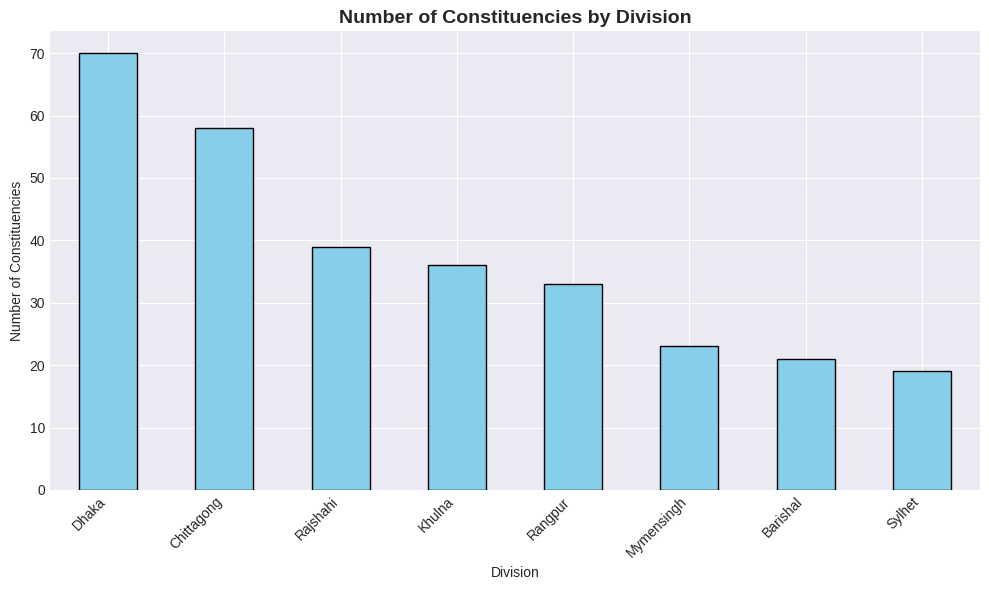


 2. Average Poverty Rate by Division


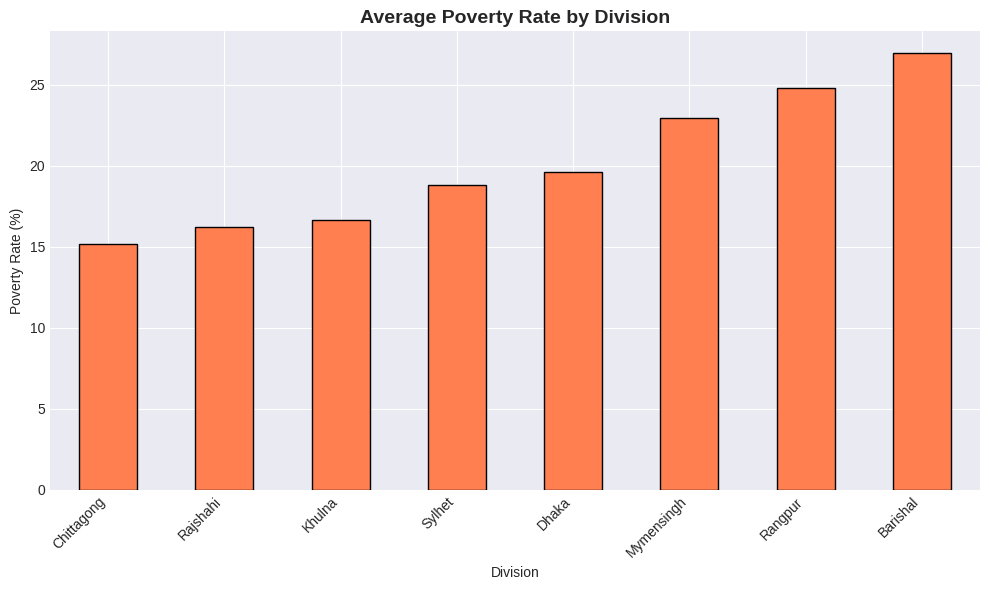


 3. Average Literacy Rate by Division


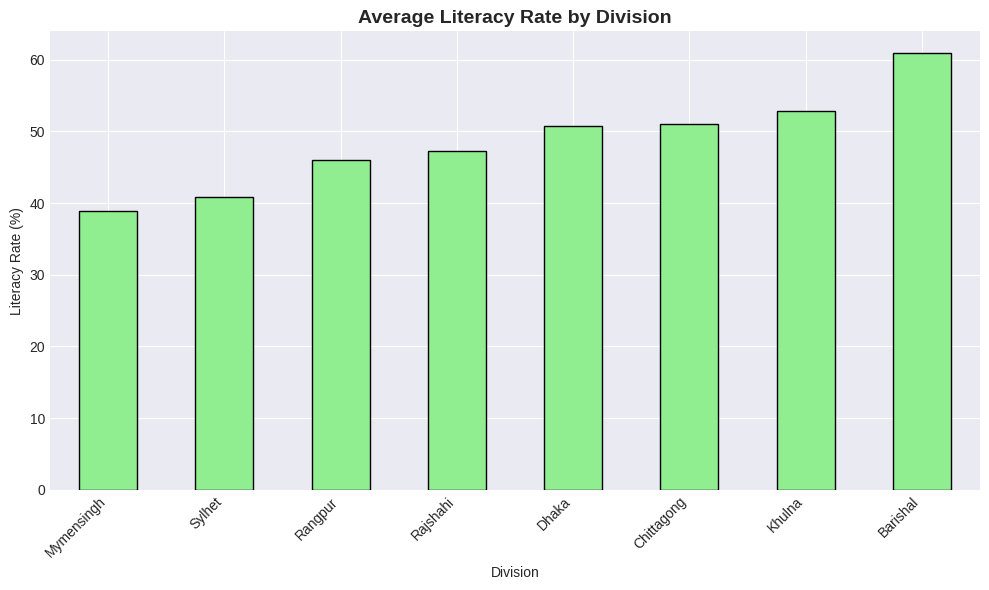


 4. Average Winning Margin by Division


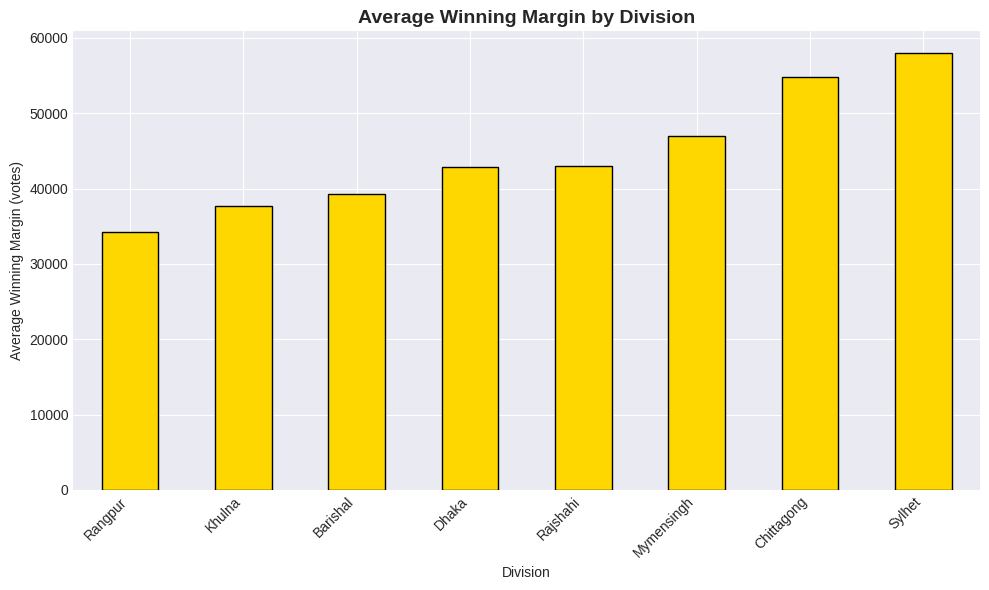

 EDA Part 1 complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load data
df = pd.read_csv(f'{PROCESSED_DIR}/election_clean.csv')
df_normal = df[df['status'] == 'Normal'].copy()

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS - PART 1")
print("=" * 60)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Constituencies by Division
print("\n 1. Constituencies by Division")
fig1, ax1 = plt.subplots(figsize=(10, 6))
division_counts = df_normal['division'].value_counts()
division_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Number of Constituencies by Division', fontsize=14, fontweight='bold')
ax1.set_xlabel('Division')
ax1.set_ylabel('Number of Constituencies')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/constituencies_by_division.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Average Poverty Rate by Division
print("\n 2. Average Poverty Rate by Division")
fig2, ax2 = plt.subplots(figsize=(10, 6))
poverty_by_div = df_normal.groupby('division')['poverty_rate'].mean().sort_values()
poverty_by_div.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Average Poverty Rate by Division', fontsize=14, fontweight='bold')
ax2.set_xlabel('Division')
ax2.set_ylabel('Poverty Rate (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/poverty_by_division.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Average Literacy Rate by Division
print("\n 3. Average Literacy Rate by Division")
fig3, ax3 = plt.subplots(figsize=(10, 6))
literacy_by_div = df_normal.groupby('division')['literacy_rate'].mean().sort_values()
literacy_by_div.plot(kind='bar', ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Average Literacy Rate by Division', fontsize=14, fontweight='bold')
ax3.set_xlabel('Division')
ax3.set_ylabel('Literacy Rate (%)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/literacy_by_division.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Average Winning Margin by Division
print("\n 4. Average Winning Margin by Division")
fig4, ax4 = plt.subplots(figsize=(10, 6))
margin_by_div = df_normal.groupby('division')['margin'].mean().sort_values()
margin_by_div.plot(kind='bar', ax=ax4, color='gold', edgecolor='black')
ax4.set_title('Average Winning Margin by Division', fontsize=14, fontweight='bold')
ax4.set_xlabel('Division')
ax4.set_ylabel('Average Winning Margin (votes)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/margin_by_division.png', dpi=300, bbox_inches='tight')
plt.show()

print(" EDA Part 1 complete!")

##  5. EDA and Visualizations - Part 1

This section focuses on initial exploratory data analysis (EDA) using Matplotlib and Seaborn to understand basic distributions and relationships. It generates static visualizations saved as PNG images. The visualizations include:

-   **Constituencies by Division**: A bar chart showing the number of constituencies in each division.
-   **Average Poverty Rate by Division**: A bar chart illustrating the average poverty rate across different divisions.
-   **Average Literacy Rate by Division**: A bar chart displaying the average literacy rate for each division.
-   **Average Winning Margin by Division**: A bar chart showing the average winning margin (in votes) per division.

EXPLORATORY DATA ANALYSIS - PART 2

 5. Party Analysis - Seats Won


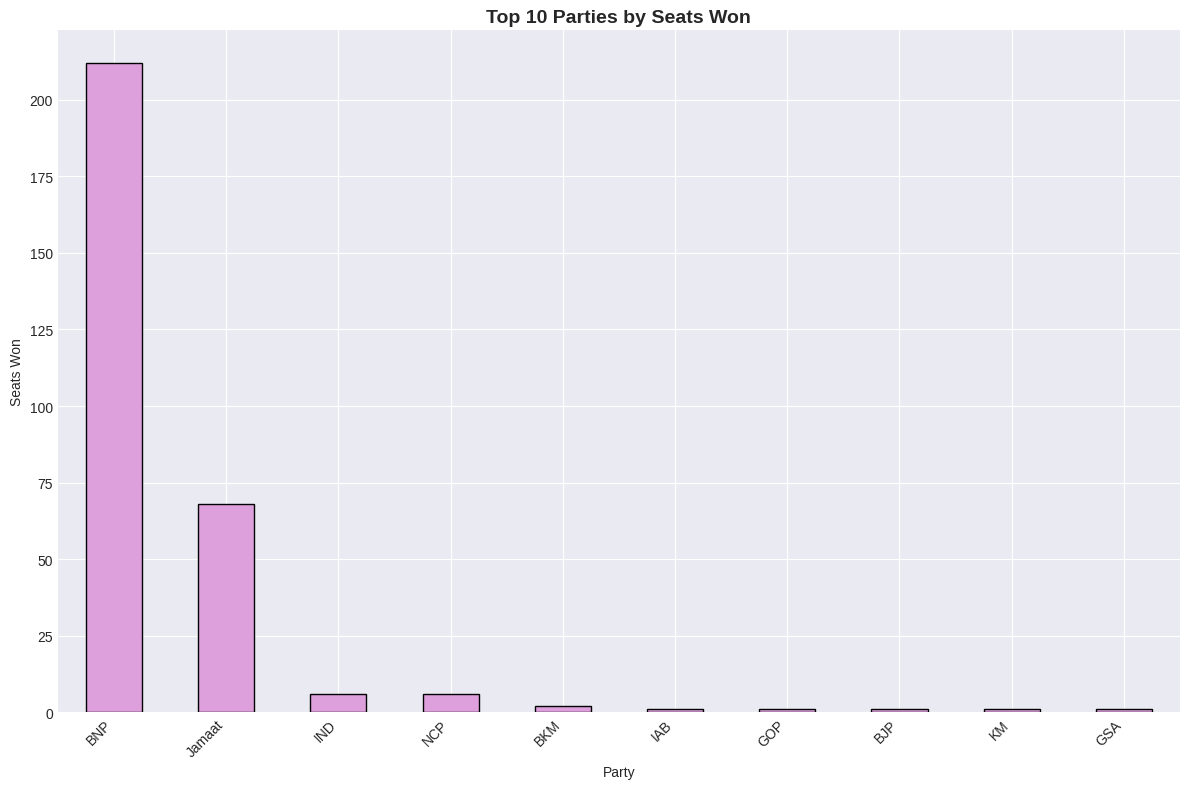


 6. Party Distribution by Division


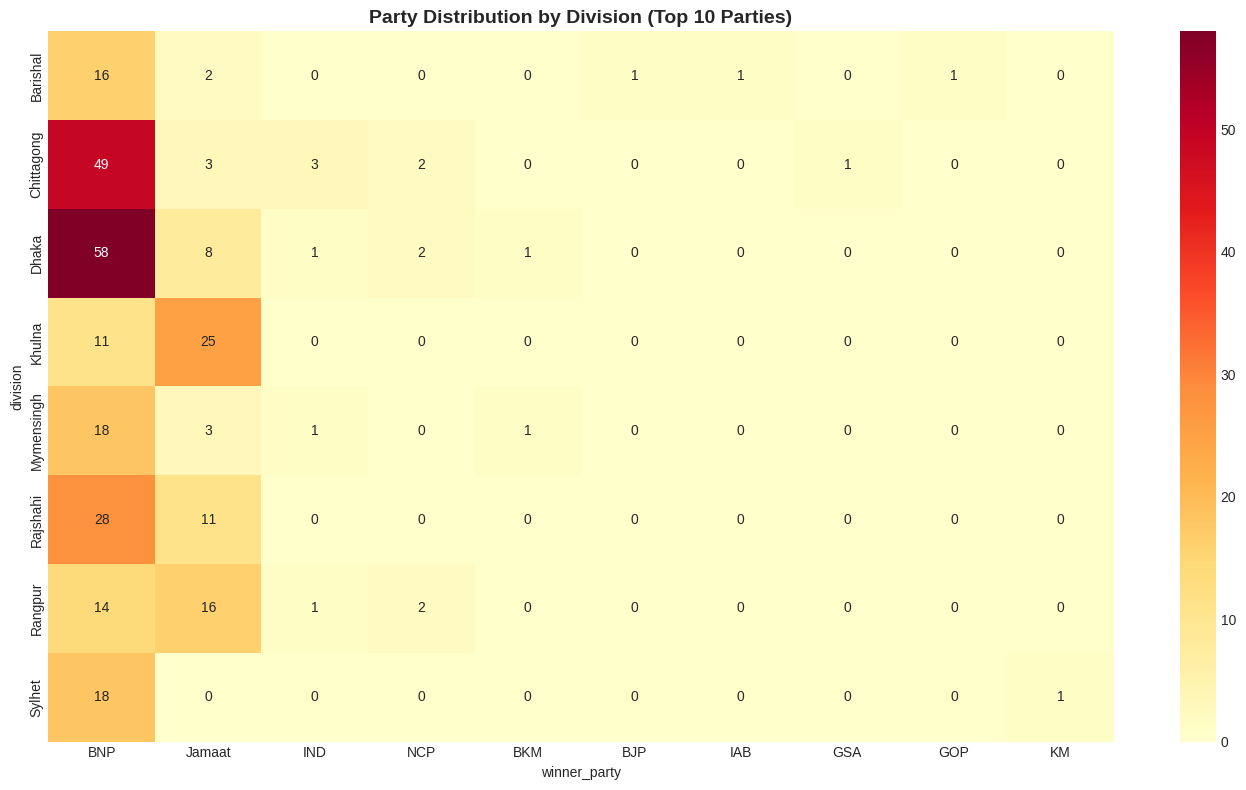


 7. Winning Margin Distribution


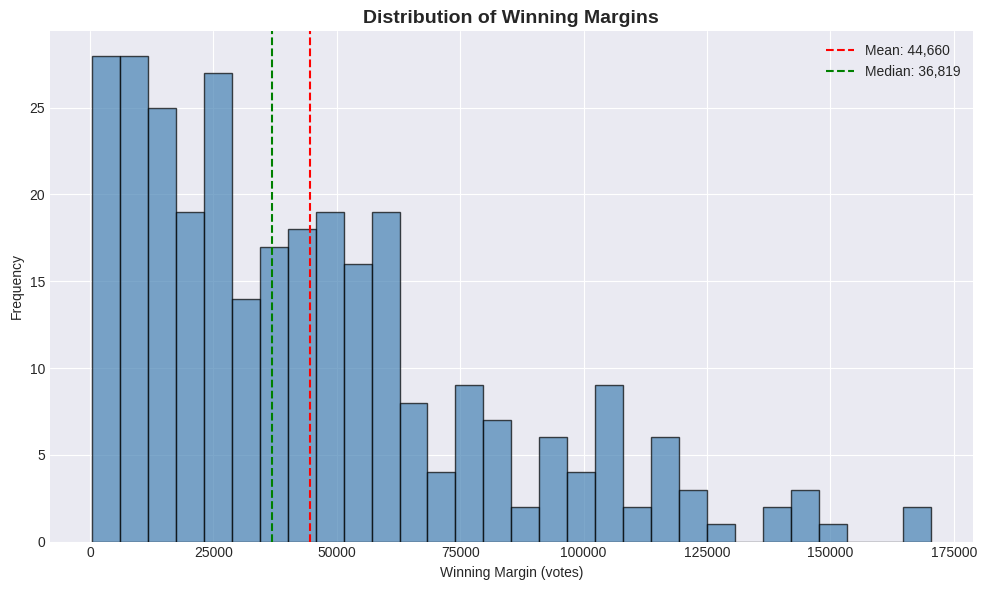


 8. Competitiveness Categories


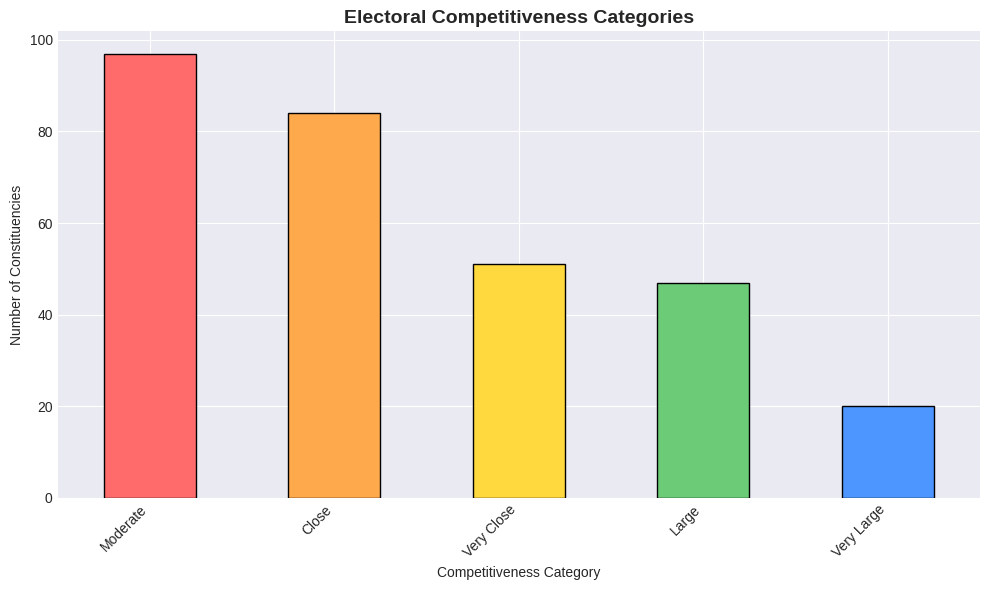

 EDA Part 2 complete!


In [ ]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS - PART 2")
print("=" * 60)

# 5. Party Analysis - Seats Won
print("\n 5. Party Analysis - Seats Won")
fig5, ax5 = plt.subplots(figsize=(12, 8))
party_seats = df_normal['winner_party'].value_counts().head(10)
party_seats.plot(kind='bar', ax=ax5, color='plum', edgecolor='black')
ax5.set_title('Top 10 Parties by Seats Won', fontsize=14, fontweight='bold')
ax5.set_xlabel('Party')
ax5.set_ylabel('Seats Won')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/party_seats.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Party Distribution by Division (Heatmap)
print("\n 6. Party Distribution by Division")
party_division_matrix = pd.crosstab(df_normal['division'], df_normal['winner_party'])
party_division_top = party_division_matrix[party_division_matrix.sum().sort_values(ascending=False).head(10).index]

fig6, ax6 = plt.subplots(figsize=(14, 8))
sns.heatmap(party_division_top, annot=True, fmt='d', cmap='YlOrRd', ax=ax6)
ax6.set_title('Party Distribution by Division (Top 10 Parties)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/party_division_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Winning Margin Distribution
print("\n 7. Winning Margin Distribution")
fig7, ax7 = plt.subplots(figsize=(10, 6))
df_normal['margin'].hist(bins=30, ax=ax7, color='steelblue', edgecolor='black', alpha=0.7)
ax7.set_title('Distribution of Winning Margins', fontsize=14, fontweight='bold')
ax7.set_xlabel('Winning Margin (votes)')
ax7.set_ylabel('Frequency')
ax7.axvline(df_normal['margin'].mean(), color='red', linestyle='--', label=f"Mean: {df_normal['margin'].mean():,.0f}")
ax7.axvline(df_normal['margin'].median(), color='green', linestyle='--', label=f"Median: {df_normal['margin'].median():,.0f}")
ax7.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/margin_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Competitiveness Categories
print("\n 8. Competitiveness Categories")
fig8, ax8 = plt.subplots(figsize=(10, 6))
competitiveness_counts = df_normal['competitiveness'].value_counts()
colors = ['#ff6b6b', '#ffa94d', '#ffd93d', '#6bcb77', '#4d96ff']
competitiveness_counts.plot(kind='bar', ax=ax8, color=colors[:len(competitiveness_counts)], edgecolor='black')
ax8.set_title('Electoral Competitiveness Categories', fontsize=14, fontweight='bold')
ax8.set_xlabel('Competitiveness Category')
ax8.set_ylabel('Number of Constituencies')
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/competitiveness_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print(" EDA Part 2 complete!")

## 6. EDA and Visualizations - Part 2

This section continues the exploratory data analysis, delving into party performance, competitiveness, and margin distributions using Matplotlib and Seaborn. The visualizations generated are:

-   **Party Analysis - Seats Won**: A bar chart showing the top 10 parties by the number of seats won.
-   **Party Distribution by Division (Heatmap)**: A heatmap illustrating how the top parties are distributed across different divisions.
-   **Winning Margin Distribution**: A histogram showing the distribution of winning margins across all normal constituencies, with mean and median indicated.
-   **Competitiveness Categories**: A bar chart displaying the count of constituencies falling into different competitiveness categories (e.g., Very Close, Close, Moderate, Large, Very Large) based on margin percentage.

SOCIOECONOMIC ANALYSIS

 9. Poverty Rate vs Literacy Rate


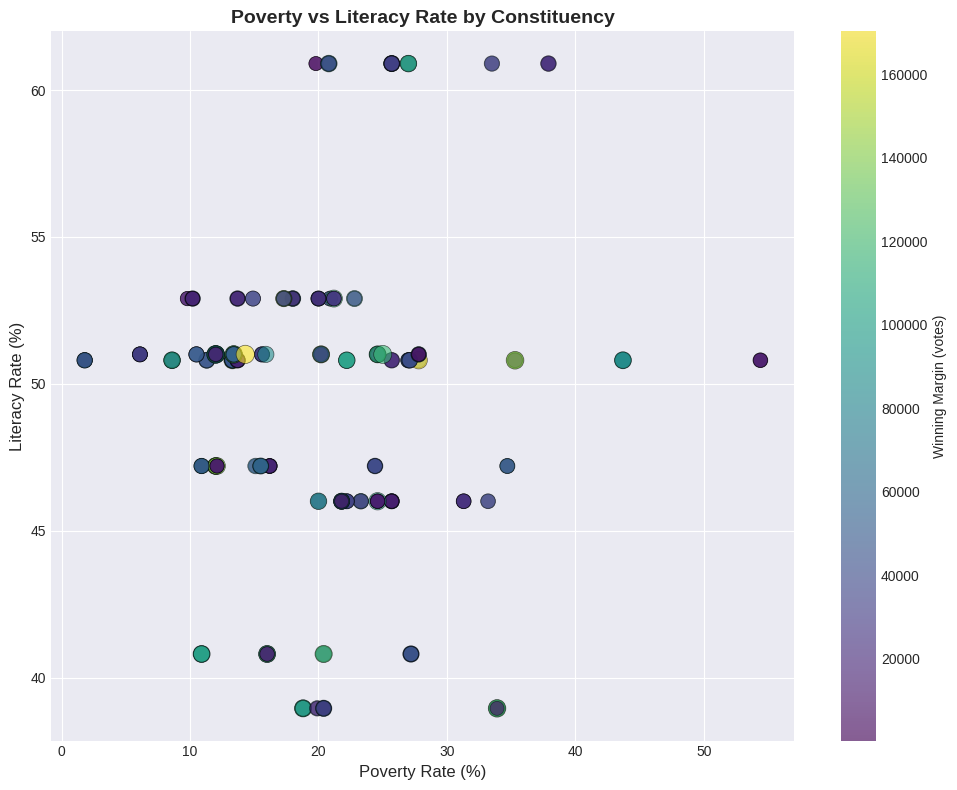


 10. Poverty Rate vs Winning Margin


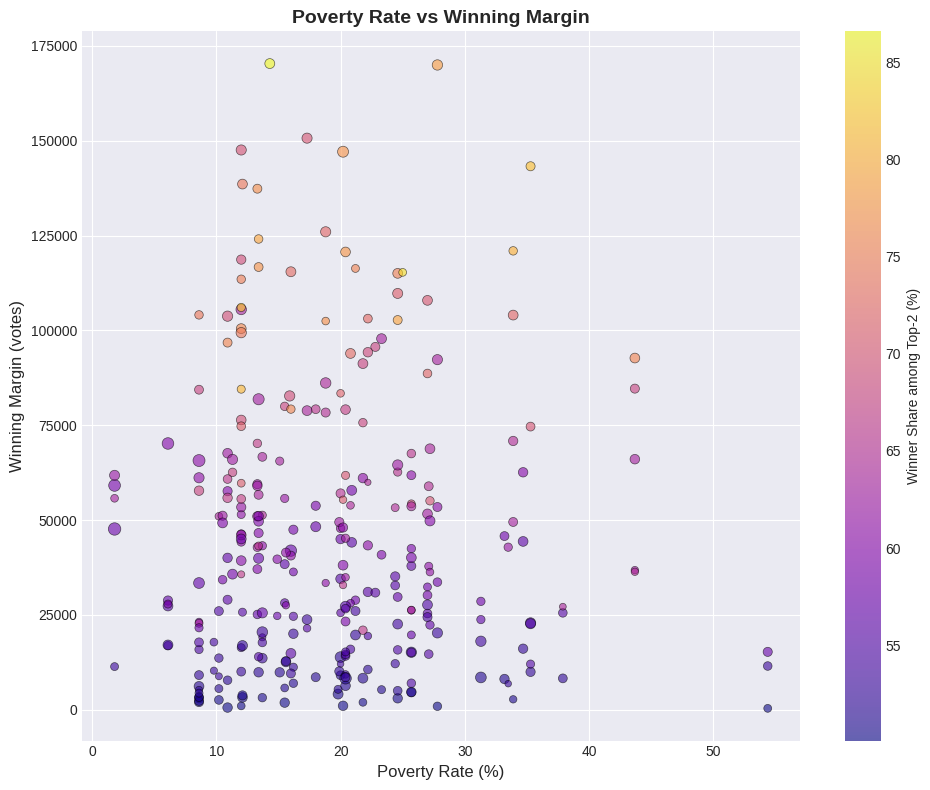


 11. Literacy Rate vs Winning Margin


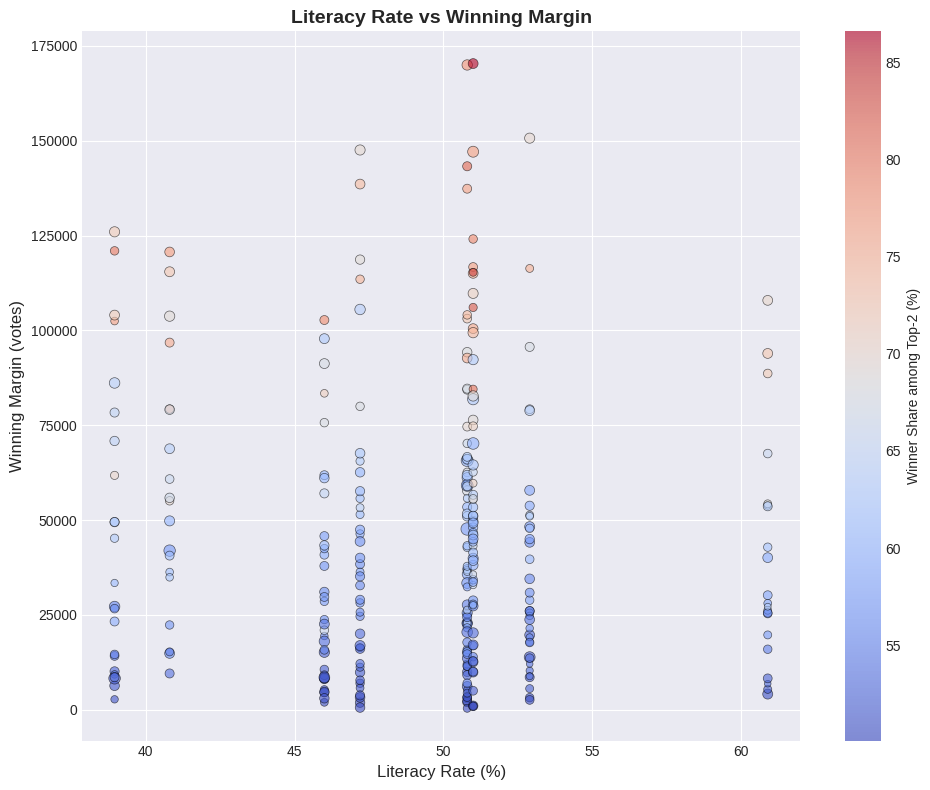


 12. Poverty Rate vs Winner Share


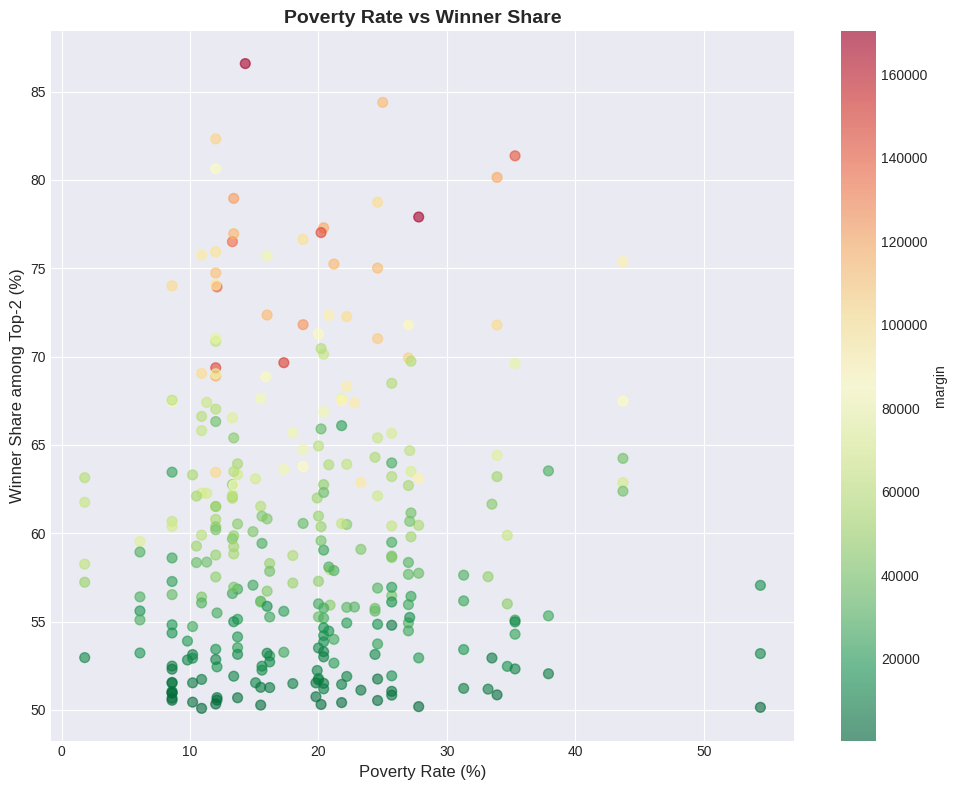


 Socioeconomic Analysis complete!


In [ ]:
print("=" * 60)
print("SOCIOECONOMIC ANALYSIS")
print("=" * 60)

# 9. Poverty vs Literacy Scatter
print("\n 9. Poverty Rate vs Literacy Rate")
fig9, ax9 = plt.subplots(figsize=(10, 8))
scatter = ax9.scatter(
    df_normal['poverty_rate'],
    df_normal['literacy_rate'],
    c=df_normal['margin'],
    cmap='viridis',
    s=df_normal['winner_share_top2'] * 2,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
ax9.set_xlabel('Poverty Rate (%)', fontsize=12)
ax9.set_ylabel('Literacy Rate (%)', fontsize=12)
ax9.set_title('Poverty vs Literacy Rate by Constituency', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Winning Margin (votes)')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/poverty_vs_literacy.png', dpi=300, bbox_inches='tight')
plt.show()

# 10. Poverty vs Winning Margin
print("\n 10. Poverty Rate vs Winning Margin")
fig10, ax10 = plt.subplots(figsize=(10, 8))
scatter2 = ax10.scatter(
    df_normal['poverty_rate'],
    df_normal['margin'],
    c=df_normal['winner_share_top2'],
    cmap='plasma',
    s=df_normal['total_voters'] / 10000,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
ax10.set_xlabel('Poverty Rate (%)', fontsize=12)
ax10.set_ylabel('Winning Margin (votes)', fontsize=12)
ax10.set_title('Poverty Rate vs Winning Margin', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(scatter2)
cbar2.set_label('Winner Share among Top-2 (%)')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/poverty_vs_margin.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Literacy vs Winning Margin
print("\n 11. Literacy Rate vs Winning Margin")
fig11, ax11 = plt.subplots(figsize=(10, 8))
scatter3 = ax11.scatter(
    df_normal['literacy_rate'],
    df_normal['margin'],
    c=df_normal['winner_share_top2'],
    cmap='coolwarm',
    s=df_normal['total_voters'] / 10000,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
ax11.set_xlabel('Literacy Rate (%)', fontsize=12)
ax11.set_ylabel('Winning Margin (votes)', fontsize=12)
ax11.set_title('Literacy Rate vs Winning Margin', fontsize=14, fontweight='bold')
cbar3 = plt.colorbar(scatter3)
cbar3.set_label('Winner Share among Top-2 (%)')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/literacy_vs_margin.png', dpi=300, bbox_inches='tight')
plt.show()

# 12. Poverty vs Winner Share
print("\n 12. Poverty Rate vs Winner Share")
fig12, ax12 = plt.subplots(figsize=(10, 8))
df_normal.plot.scatter(
    x='poverty_rate',
    y='winner_share_top2',
    c='margin',
    cmap='RdYlGn_r',
    s=50,
    alpha=0.6,
    ax=ax12
)
ax12.set_xlabel('Poverty Rate (%)', fontsize=12)
ax12.set_ylabel('Winner Share among Top-2 (%)', fontsize=12)
ax12.set_title('Poverty Rate vs Winner Share', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/poverty_vs_winnershare.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Socioeconomic Analysis complete!")

##  7. Socioeconomic Analysis

This section explores the relationships between socioeconomic indicators and election outcomes using scatter plots. The visualizations include:

-   **Poverty vs Literacy Scatter**: A scatter plot showing the relationship between poverty rate and literacy rate, with points colored by winning margin and sized by winner share among the top two candidates.
-   **Poverty vs Winning Margin**: A scatter plot examining the relationship between poverty rate and winning margin, with points colored by winner share and sized by total voters.
-   **Literacy vs Winning Margin**: A scatter plot similar to the above, but showing the relationship between literacy rate and winning margin.
-   **Poverty vs Winner Share**: A scatter plot depicting the relationship between poverty rate and winner's share among the top two candidates, with points colored by winning margin.

DEMOGRAPHIC ANALYSIS

 13. Gender Distribution by Division


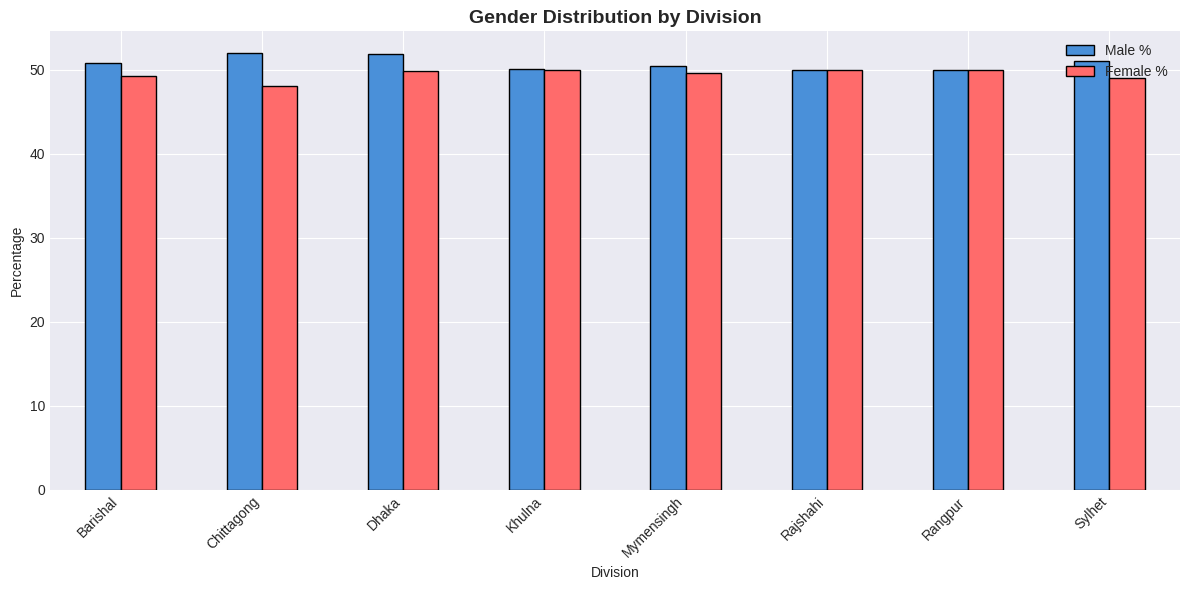


 14. Gender Gap by Division


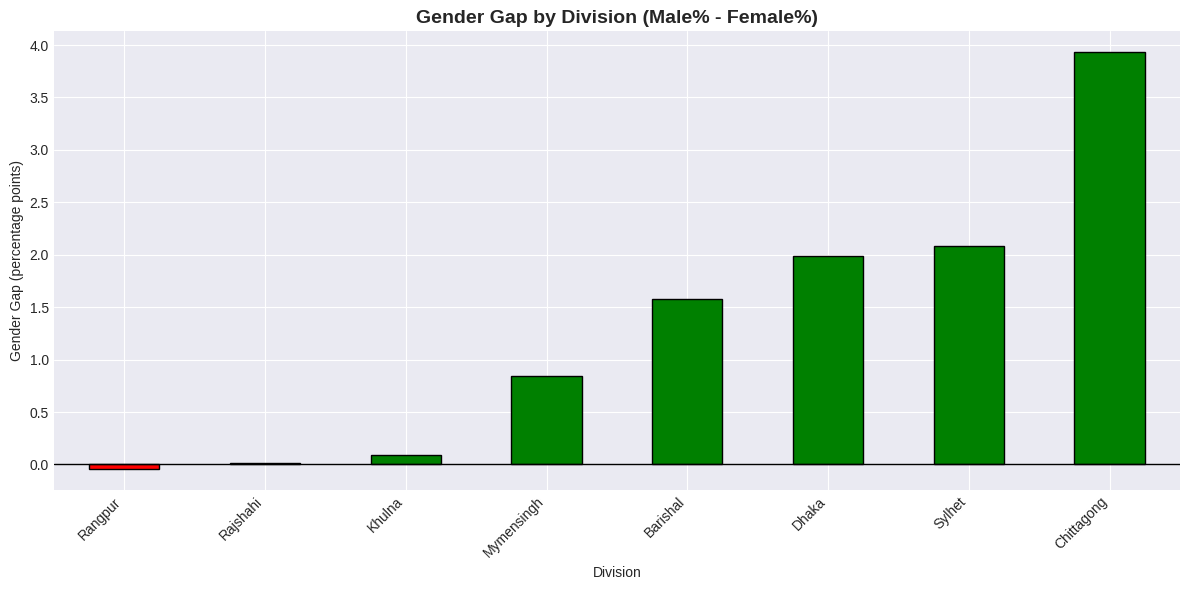


 15. Female Voter Distribution by Division


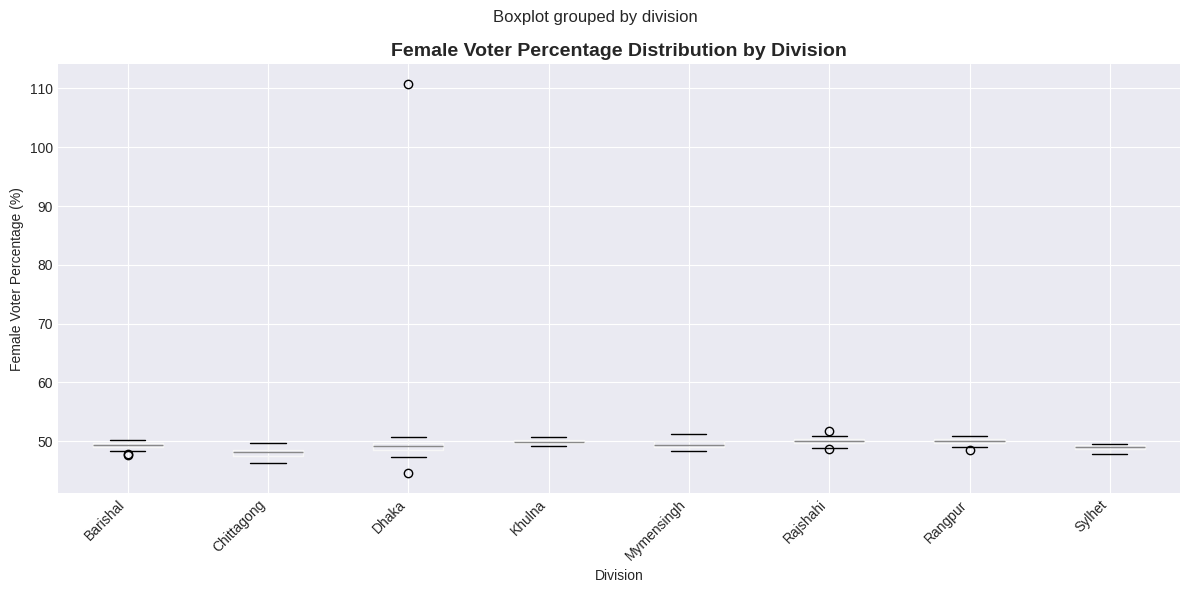


 16. Transgender Voter Distribution


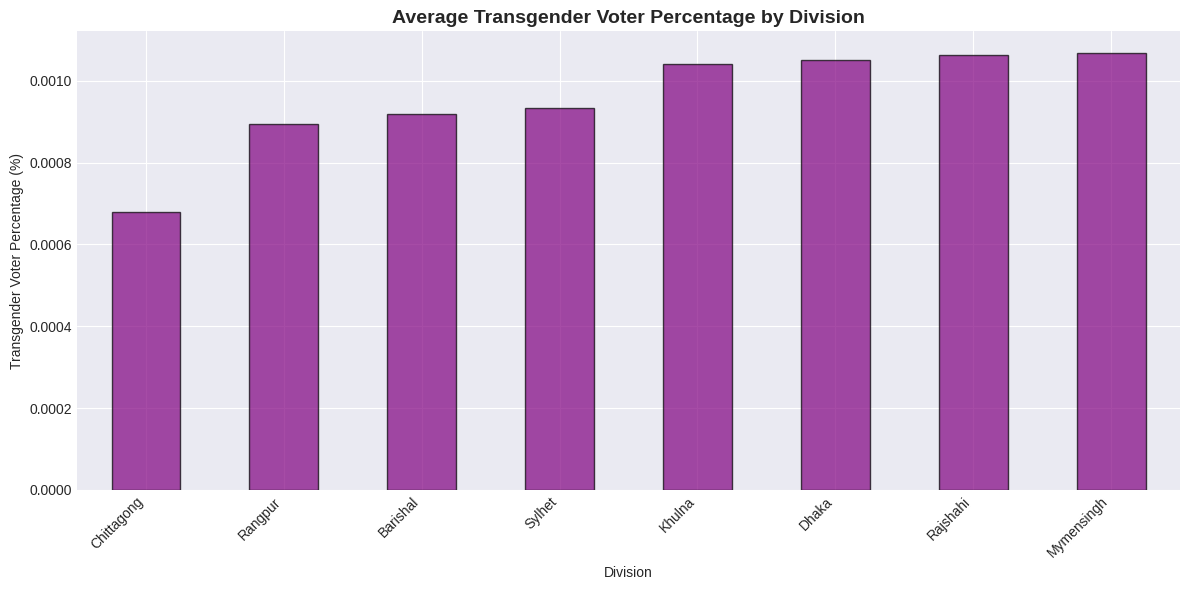

 Demographic Analysis complete!


In [ ]:
print("=" * 60)
print("DEMOGRAPHIC ANALYSIS")
print("=" * 60)

# 13. Gender Distribution by Division
print("\n 13. Gender Distribution by Division")
fig13, ax13 = plt.subplots(figsize=(12, 6))
gender_by_division = df_normal.groupby('division')[['male_pct', 'female_pct']].mean()
gender_by_division.plot(kind='bar', ax=ax13, color=['#4A90D9', '#FF6B6B'], edgecolor='black')
ax13.set_title('Gender Distribution by Division', fontsize=14, fontweight='bold')
ax13.set_xlabel('Division')
ax13.set_ylabel('Percentage')
ax13.legend(['Male %', 'Female %'])
ax13.set_xticklabels(ax13.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/gender_by_division.png', dpi=300, bbox_inches='tight')
plt.show()

# 14. Gender Gap by Division
print("\n 14. Gender Gap by Division")
fig14, ax14 = plt.subplots(figsize=(12, 6))
gender_gap_by_div = df_normal.groupby('division')['gender_gap'].mean().sort_values()
colors_gap = ['red' if x < 0 else 'green' for x in gender_gap_by_div]
gender_gap_by_div.plot(kind='bar', ax=ax14, color=colors_gap, edgecolor='black')
ax14.set_title('Gender Gap by Division (Male% - Female%)', fontsize=14, fontweight='bold')
ax14.set_xlabel('Division')
ax14.set_ylabel('Gender Gap (percentage points)')
ax14.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax14.set_xticklabels(ax14.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/gender_gap_by_division.png', dpi=300, bbox_inches='tight')
plt.show()

# 15. Female Voter Distribution
print("\n 15. Female Voter Distribution by Division")
fig15, ax15 = plt.subplots(figsize=(12, 6))
df_normal.boxplot(column='female_pct', by='division', ax=ax15)
ax15.set_title('Female Voter Percentage Distribution by Division', fontsize=14, fontweight='bold')
ax15.set_xlabel('Division')
ax15.set_ylabel('Female Voter Percentage (%)')
ax15.set_xticklabels(ax15.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/female_voter_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 16. Transgender Voter Distribution
print("\n 16. Transgender Voter Distribution")
fig16, ax16 = plt.subplots(figsize=(12, 6))
trans_by_div = df_normal.groupby('division')['transgender_pct'].mean().sort_values()
trans_by_div.plot(kind='bar', ax=ax16, color='purple', edgecolor='black', alpha=0.7)
ax16.set_title('Average Transgender Voter Percentage by Division', fontsize=14, fontweight='bold')
ax16.set_xlabel('Division')
ax16.set_ylabel('Transgender Voter Percentage (%)')
ax16.set_xticklabels(ax16.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/transgender_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Demographic Analysis complete!")

##  8. Demographic Analysis

This section focuses on understanding voter demographics and their distribution across divisions. The visualizations generated are:

-   **Gender Distribution by Division**: A grouped bar chart showing the average male and female voter percentages for each division.
-   **Gender Gap by Division**: A bar chart illustrating the average `gender_gap` (male % - female %) across divisions, indicating divisions with a higher proportion of male vs. female voters.
-   **Female Voter Distribution**: A box plot showing the distribution of female voter percentages across different divisions.
-   **Transgender Voter Distribution**: A bar chart displaying the average transgender voter percentage for each division.

STATISTICAL ANALYSIS & CORRELATION

 17. Correlation Heatmap


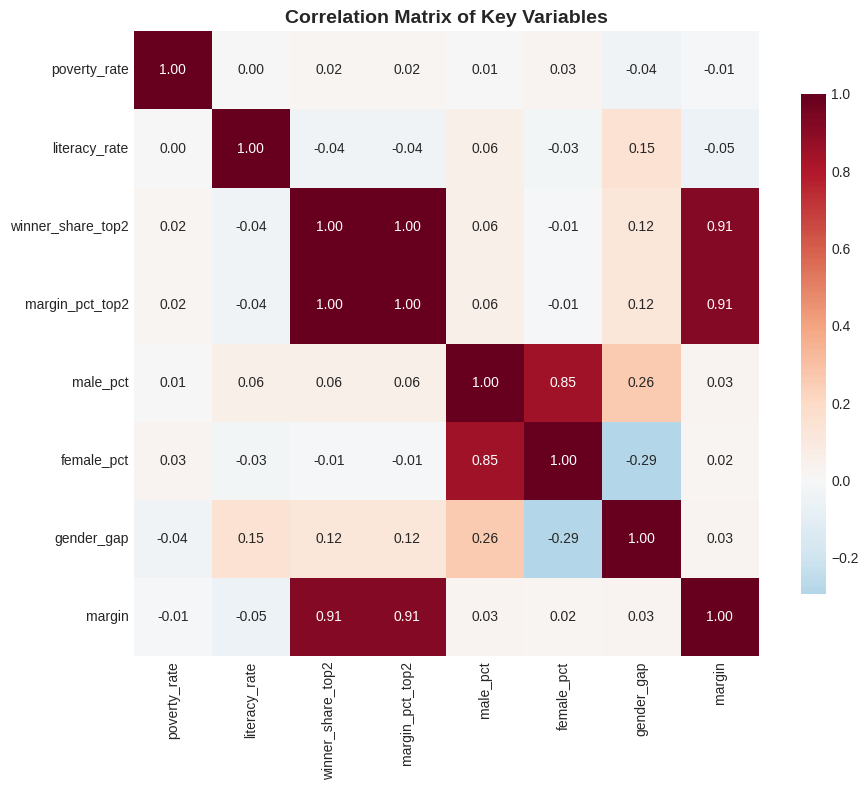


 18. Key Correlations Summary


,Relationship,Correlation,Strength
0,Poverty vs Literacy,0.000549,Weak
1,Poverty vs Winner Share,0.016810,Weak
2,Poverty vs Margin,-0.013062,Weak
3,Literacy vs Winner Share,-0.038792,Weak
4,Literacy vs Margin,-0.051202,Weak
5,Gender Gap vs Poverty,-0.042573,Weak
6,Gender Gap vs Literacy,0.152502,Weak



 19. Descriptive Statistics


,poverty_rate,literacy_rate,winner_share_top2,margin_pct_top2,male_pct,female_pct,gender_gap,margin
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,19.24,49.25,60.11,20.22,50.98,49.43,1.54,44659.66
std,9.08,5.18,7.75,15.51,3.67,3.70,2.04,35727.27
min,1.80,38.95,50.09,0.18,48.23,44.53,-3.53,385.00
25%,12.00,46.60,53.88,7.76,50.00,48.56,-0.01,15930.50
50%,18.80,50.80,58.60,17.21,50.60,49.42,1.17,36819.00
75%,24.60,51.00,63.92,27.84,51.45,50.02,2.90,61472.50
max,54.40,60.90,86.59,73.17,111.64,110.78,10.93,170322.00


 Statistical Analysis complete!


In [ ]:
print("=" * 60)
print("STATISTICAL ANALYSIS & CORRELATION")
print("=" * 60)

# Select numerical columns for correlation
correlation_columns = [
    'poverty_rate',
    'literacy_rate',
    'winner_share_top2',
    'margin_pct_top2',
    'male_pct',
    'female_pct',
    'gender_gap',
    'margin'
]

# Compute correlation matrix
corr_matrix = df_normal[correlation_columns].corr()

# 17. Correlation Heatmap
print("\n 17. Correlation Heatmap")
fig17, ax17 = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax17
)
ax17.set_title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 18. Key Correlations Summary
print("\n 18. Key Correlations Summary")
key_correlations = [
    ('Poverty vs Literacy', corr_matrix.loc['poverty_rate', 'literacy_rate']),
    ('Poverty vs Winner Share', corr_matrix.loc['poverty_rate', 'winner_share_top2']),
    ('Poverty vs Margin', corr_matrix.loc['poverty_rate', 'margin']),
    ('Literacy vs Winner Share', corr_matrix.loc['literacy_rate', 'winner_share_top2']),
    ('Literacy vs Margin', corr_matrix.loc['literacy_rate', 'margin']),
    ('Gender Gap vs Poverty', corr_matrix.loc['gender_gap', 'poverty_rate']),
    ('Gender Gap vs Literacy', corr_matrix.loc['gender_gap', 'literacy_rate']),
]

corr_df = pd.DataFrame(key_correlations, columns=['Relationship', 'Correlation'])
corr_df['Strength'] = corr_df['Correlation'].apply(
    lambda x: 'Strong' if np.abs(x) > 0.5 else 'Moderate' if np.abs(x) > 0.3 else 'Weak'
)
display(corr_df)

# Save correlation matrix
corr_matrix.to_csv(f'{PROJECT_ROOT}/outputs/tables/correlation_matrix.csv')

# 19. Descriptive Statistics
print("\n 19. Descriptive Statistics")
desc_stats = df_normal[correlation_columns].describe().round(2)
display(desc_stats)

# Save descriptive statistics
desc_stats.to_csv(f'{PROJECT_ROOT}/outputs/tables/descriptive_statistics.csv')

print(" Statistical Analysis complete!")

##  9. Statistical Analysis & Correlation

This section performs statistical analysis to understand the relationships and distributions of key variables. It includes:

-   **Correlation Heatmap**: A heatmap visualizing the correlation matrix of selected numerical variables such as poverty rate, literacy rate, winner share, margin percentage, gender percentages, and gender gap. This helps identify strong and weak linear relationships between these factors.
-   **Key Correlations Summary**: A table summarizing specific key correlations, classifying their strength (Strong, Moderate, Weak).
-   **Descriptive Statistics**: A table providing summary statistics (mean, standard deviation, min, max, quartiles) for the selected numerical columns, offering insights into their central tendency and spread.

CLUSTERING ANALYSIS

 20. Optimal Number of Clusters


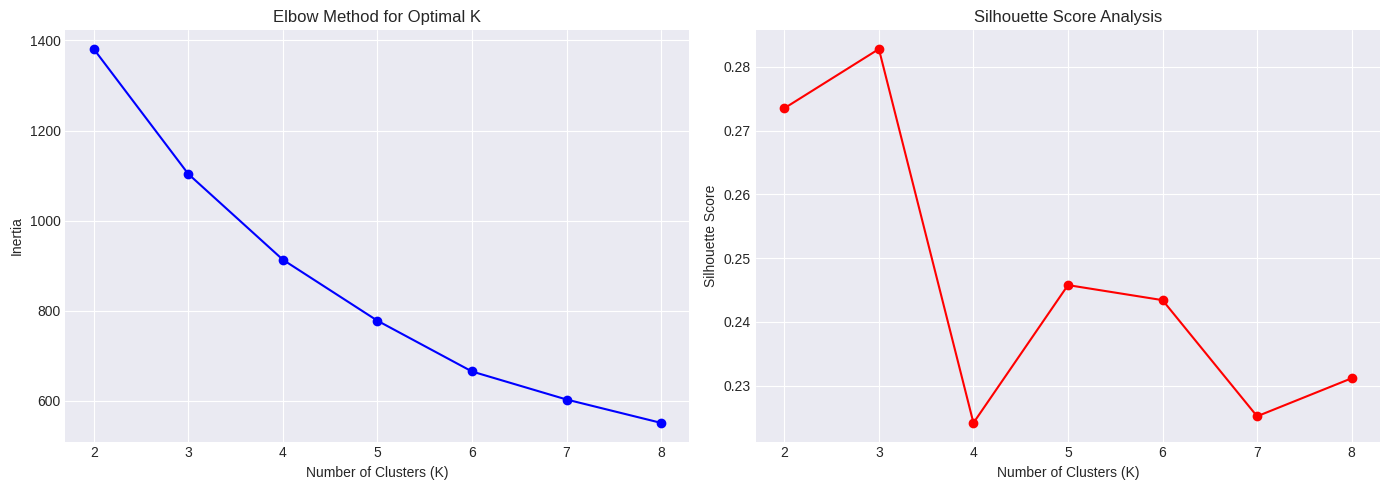


 21. Cluster Characteristics


,poverty_rate_mean,poverty_rate_std,poverty_rate_min,poverty_rate_max,literacy_rate_mean,literacy_rate_std,literacy_rate_min,literacy_rate_max,winner_share_top2_mean,winner_share_top2_std,margin_pct_top2_mean,margin_pct_top2_std,female_pct_mean,gender_gap_mean,division_<lambda>,winner_party_<lambda>,constituencies
cluster,,,,,,,,,,,,,,,,,
0.0,15.41,7.63,1.8,37.9,52.40,3.52,47.20,60.9,56.90,4.16,13.80,8.33,48.98,2.04,Dhaka,BNP,134
1.0,24.61,9.07,10.9,54.4,45.19,3.97,38.95,50.8,56.21,4.27,12.42,8.55,49.72,0.56,Rangpur,BNP,95
2.0,19.24,8.01,8.6,43.7,48.73,5.33,38.95,60.9,71.66,5.21,43.32,10.42,49.03,1.95,Chittagong,BNP,69
3.0,22.20,NaN,22.2,22.2,50.80,NaN,50.80,50.8,63.90,NaN,27.81,NaN,110.78,0.86,Dhaka,BNP,1



 22. Feature Distribution by Cluster


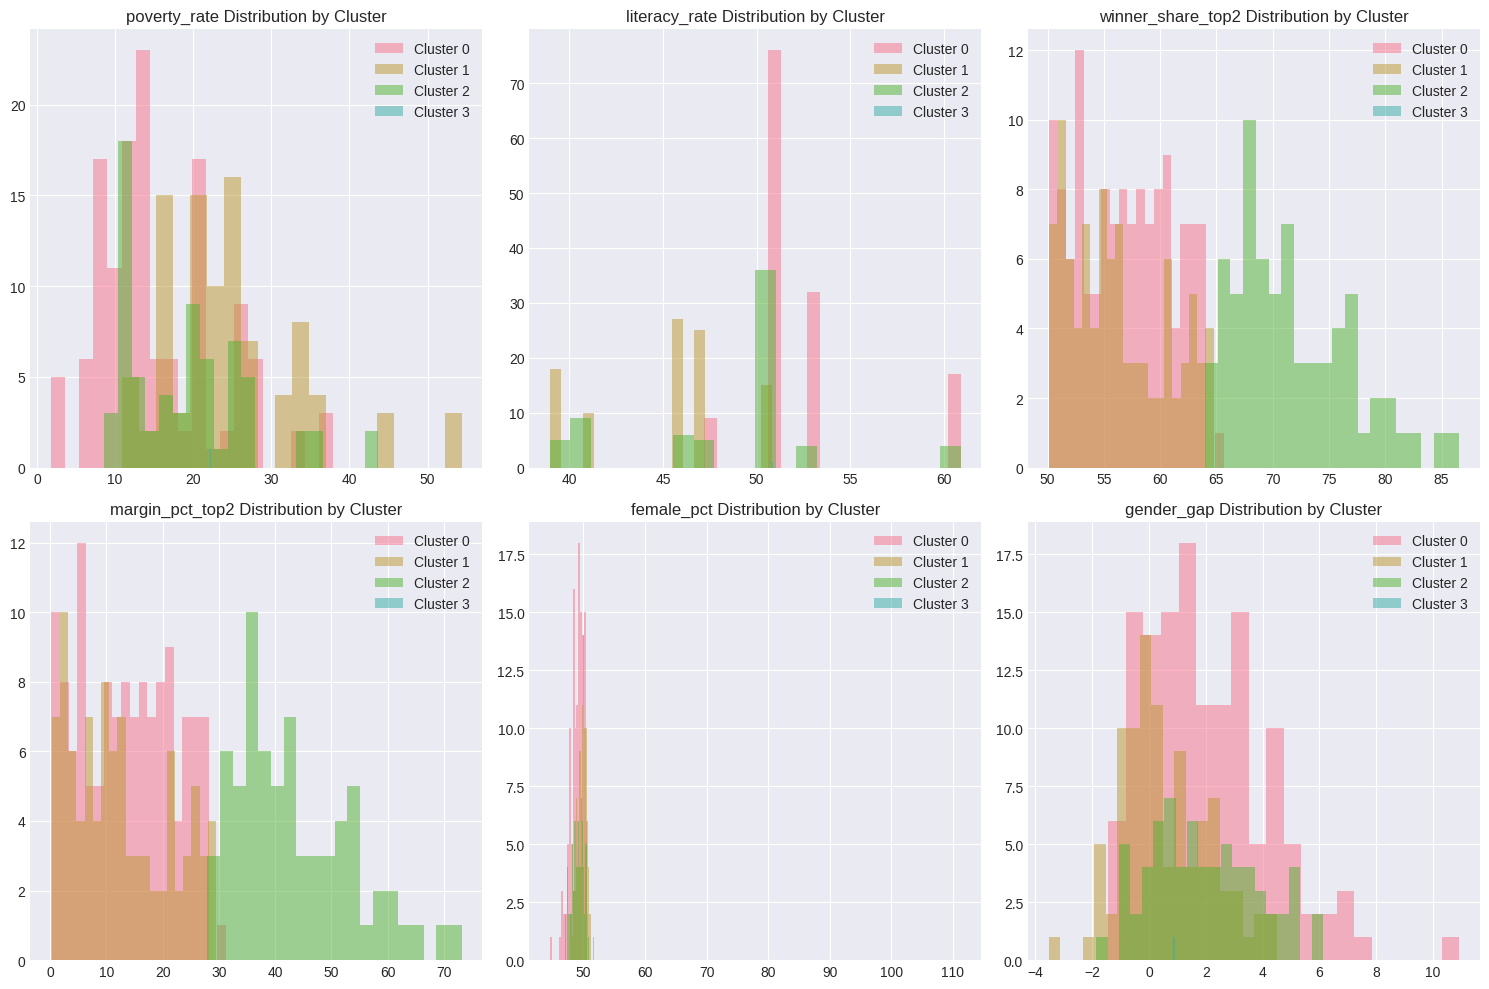


 23. Cluster Visualization with PCA


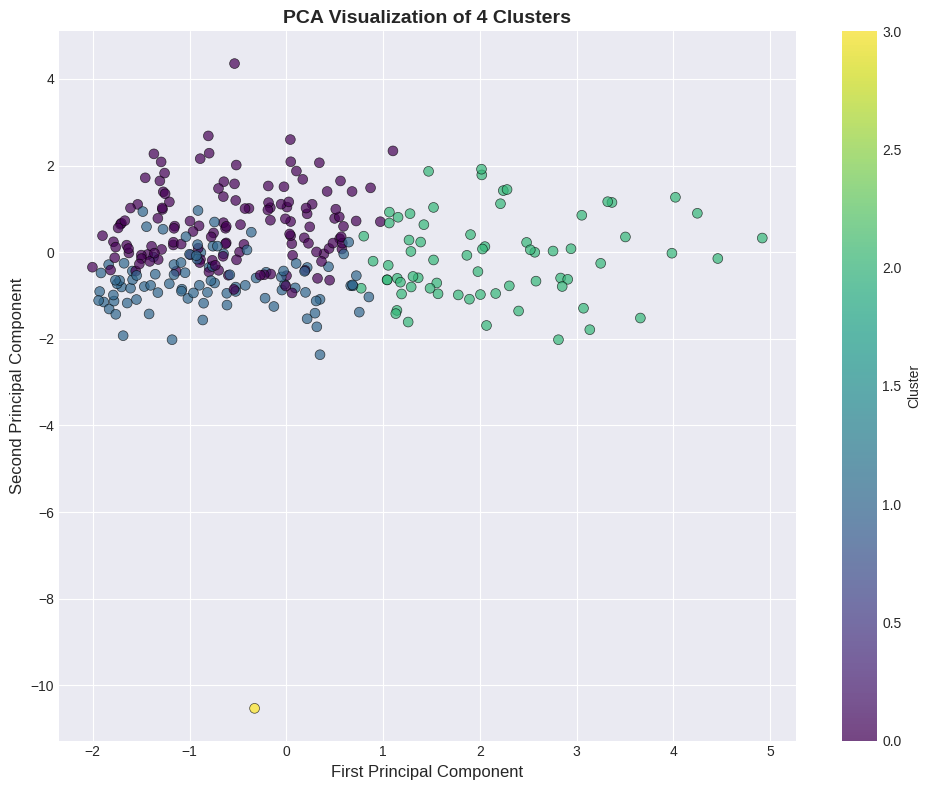


 24. Cluster Interpretations

🔹 Cluster 0:
   • Constituencies: 134
   • Avg Poverty Rate: 15.4%
   • Avg Literacy Rate: 52.4%
   • Avg Winner Share: 56.9%
   • Avg Female %: 49.0%
   • Gender Gap: 2.0 pts
   • Dominant Division: Dhaka
   • Dominant Party: BNP

🔹 Cluster 1:
   • Constituencies: 95
   • Avg Poverty Rate: 24.6%
   • Avg Literacy Rate: 45.2%
   • Avg Winner Share: 56.2%
   • Avg Female %: 49.7%
   • Gender Gap: 0.6 pts
   • Dominant Division: Rangpur
   • Dominant Party: BNP

🔹 Cluster 2:
   • Constituencies: 69
   • Avg Poverty Rate: 19.2%
   • Avg Literacy Rate: 48.7%
   • Avg Winner Share: 71.7%
   • Avg Female %: 49.0%
   • Gender Gap: 2.0 pts
   • Dominant Division: Chittagong
   • Dominant Party: BNP

🔹 Cluster 3:
   • Constituencies: 1
   • Avg Poverty Rate: 22.2%
   • Avg Literacy Rate: 50.8%
   • Avg Winner Share: 63.9%
   • Avg Female %: 110.8%
   • Gender Gap: 0.9 pts
   • Dominant Division: Dhaka
   • Dominant Party: BNP

 Clustering Analysis complete!


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("=" * 60)
print("CLUSTERING ANALYSIS")
print("=" * 60)

# Select features for clustering
features = [
    'poverty_rate',
    'literacy_rate',
    'winner_share_top2',
    'margin_pct_top2',
    'female_pct',
    'gender_gap'
]

# Prepare data
df_cluster = df_normal[features].copy()
df_cluster = df_cluster.dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Find optimal K using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# 20. Elbow Method & Silhouette Score
print("\n 20. Optimal Number of Clusters")
fig20, (ax20a, ax20b) = plt.subplots(1, 2, figsize=(14, 5))

ax20a.plot(K_range, inertias, 'bo-')
ax20a.set_xlabel('Number of Clusters (K)')
ax20a.set_ylabel('Inertia')
ax20a.set_title('Elbow Method for Optimal K')
ax20a.grid(True)

ax20b.plot(K_range, silhouette_scores, 'ro-')
ax20b.set_xlabel('Number of Clusters (K)')
ax20b.set_ylabel('Silhouette Score')
ax20b.set_title('Silhouette Score Analysis')
ax20b.grid(True)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/clustering_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

# Choose optimal K
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to data
df_normal.loc[df_cluster.index, 'cluster'] = clusters

# 21. Cluster Characteristics
print("\n 21. Cluster Characteristics")
cluster_summary = df_normal.groupby('cluster').agg({
    'poverty_rate': ['mean', 'std', 'min', 'max'],
    'literacy_rate': ['mean', 'std', 'min', 'max'],
    'winner_share_top2': ['mean', 'std'],
    'margin_pct_top2': ['mean', 'std'],
    'female_pct': ['mean'],
    'gender_gap': ['mean'],
    'division': lambda x: x.value_counts().index[0] if len(x) > 0 else None,
    'winner_party': lambda x: x.value_counts().index[0] if len(x) > 0 else None,
    'constituency_no': 'count'
}).round(2)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={
    'constituency_no_count': 'constituencies'
})
display(cluster_summary)

# 22. Cluster Visualizations
print("\n 22. Feature Distribution by Cluster")
fig22, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['poverty_rate', 'literacy_rate', 'winner_share_top2',
                    'margin_pct_top2', 'female_pct', 'gender_gap']

for idx, (ax, feature) in enumerate(zip(axes.flat, features_to_plot)):
    for cluster in range(optimal_k):
        data = df_normal[df_normal['cluster'] == cluster][feature]
        ax.hist(data, alpha=0.5, label=f'Cluster {cluster}', bins=20)
    ax.set_title(f'{feature} Distribution by Cluster')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/cluster_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 23. PCA Visualization
print("\n 23. Cluster Visualization with PCA")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig23, ax23 = plt.subplots(figsize=(10, 8))
scatter_pca = ax23.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.7,
    s=50,
    edgecolors='black',
    linewidth=0.5
)
ax23.set_xlabel('First Principal Component', fontsize=12)
ax23.set_ylabel('Second Principal Component', fontsize=12)
ax23.set_title(f'PCA Visualization of {optimal_k} Clusters', fontsize=14, fontweight='bold')
cbar_pca = plt.colorbar(scatter_pca)
cbar_pca.set_label('Cluster')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# 24. Cluster Interpretations
print("\n 24. Cluster Interpretations")
print("=" * 60)

for cluster in range(optimal_k):
    cluster_data = df_normal[df_normal['cluster'] == cluster]
    print(f"\n🔹 Cluster {cluster}:")
    print(f"   • Constituencies: {len(cluster_data)}")
    print(f"   • Avg Poverty Rate: {cluster_data['poverty_rate'].mean():.1f}%")
    print(f"   • Avg Literacy Rate: {cluster_data['literacy_rate'].mean():.1f}%")
    print(f"   • Avg Winner Share: {cluster_data['winner_share_top2'].mean():.1f}%")
    print(f"   • Avg Female %: {cluster_data['female_pct'].mean():.1f}%")
    print(f"   • Gender Gap: {cluster_data['gender_gap'].mean():.1f} pts")
    print(f"   • Dominant Division: {cluster_data['division'].value_counts().index[0]}")
    print(f"   • Dominant Party: {cluster_data['winner_party'].value_counts().index[0]}")

# Save cluster results
cluster_summary.to_csv(f'{PROJECT_ROOT}/outputs/tables/cluster_summary.csv')
df_normal.to_csv(f'{PROCESSED_DIR}/election_with_clusters.csv', index=False)

print("\n Clustering Analysis complete!")

##  10. Clustering Analysis

This section applies clustering techniques to group constituencies based on their socioeconomic and electoral characteristics. The steps involved are:

-   **Feature Selection and Preparation**: Selecting relevant features (poverty rate, literacy rate, winner share, margin percentage, female percentage, gender gap) and handling missing values.
-   **Data Standardization**: Scaling the features using `StandardScaler` to ensure all features contribute equally to the clustering process.
-   **Optimal K Determination**: Using the Elbow Method (based on inertia) and Silhouette Score to determine the optimal number of clusters (`K`). Visualizations are provided to support this decision.
-   **K-Means Clustering**: Applying the K-Means algorithm with the chosen optimal `K` to assign each constituency to a cluster.
-   **Cluster Characteristics**: Summarizing the characteristics of each cluster by calculating mean/std of features, dominant division, and dominant party. This helps in interpreting what each cluster represents.
-   **Cluster Visualizations**:
    -   Histograms showing the distribution of selected features within each cluster.
    -   A PCA (Principal Component Analysis) plot to visualize the clusters in a 2D space, reducing the dimensionality of the feature space while preserving variance.
-   **Cluster Interpretations**: Providing a textual interpretation for each cluster based on its distinct characteristics.
-   **Saving Cluster Results**: The cluster summary and the original dataframe augmented with cluster assignments are saved as CSV files.

REFERENDUM ANALYSIS

 Referendum Results:


,choice,votes,percentage
0,Yes,47225980,68.26
1,No,21960231,31.74
2,Valid votes,69186211,90.30
3,Invalid or blank votes,7435196,9.70
4,Total votes,76621407,100.00
5,Registered voters/turnout,127711793,60.00


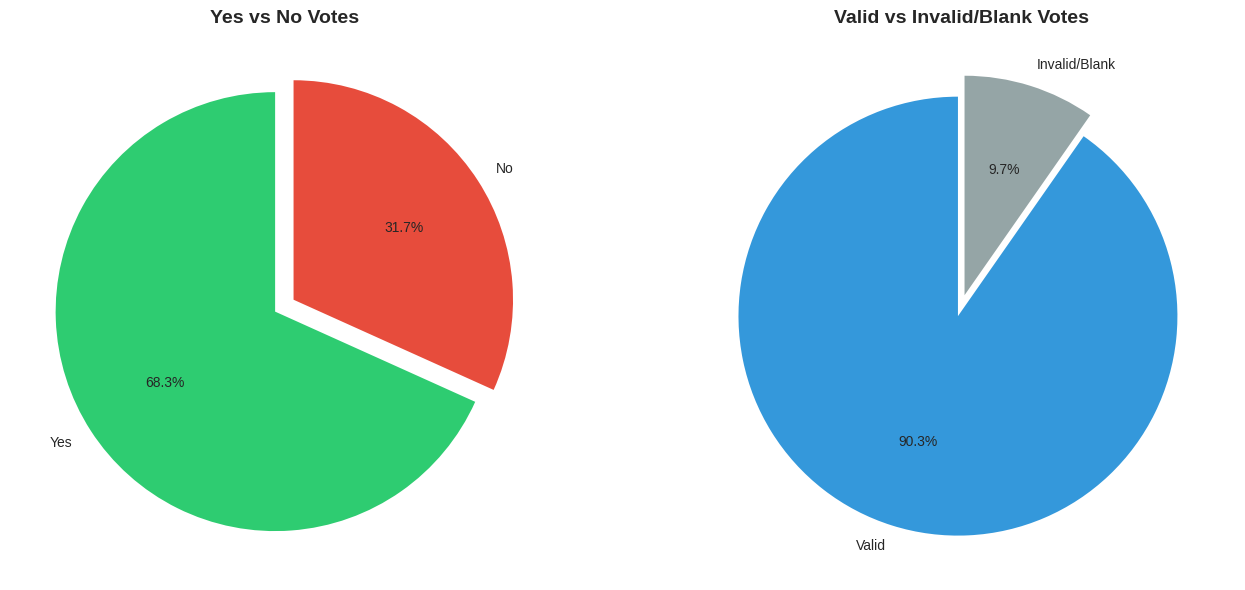


 26. Referendum Vote Composition


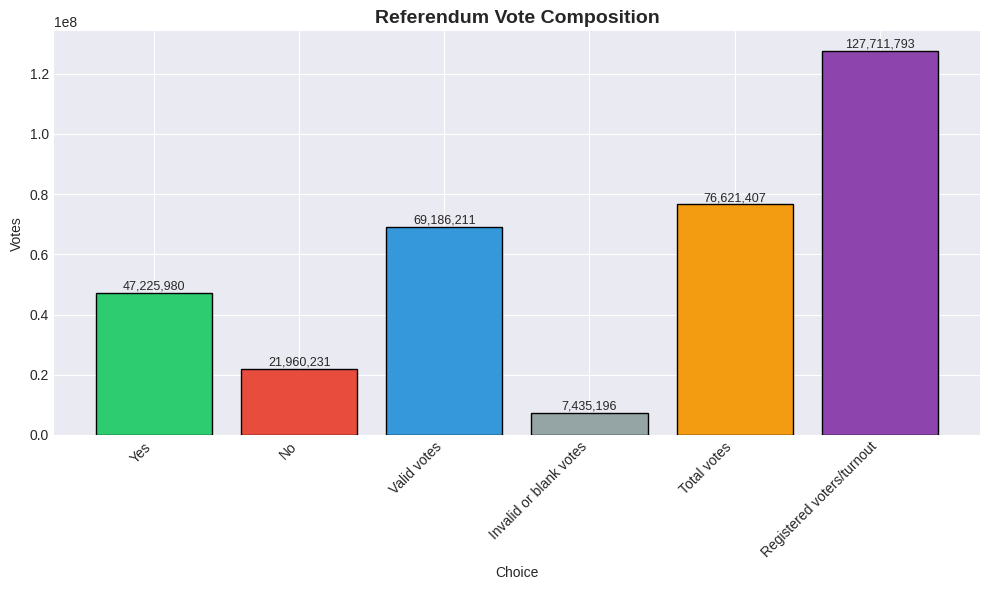


 27. Referendum Key Performance Indicators
Total Votes: 76,621,407
Valid Votes: 69,186,211
Invalid/Blank Votes: 7,435,196
Yes Votes: 47,225,980
No Votes: 21,960,231
Yes Percentage: 68.3%
No Percentage: 31.7%

 Referendum Analysis complete!


In [ ]:
print("=" * 60)
print("REFERENDUM ANALYSIS")
print("=" * 60)

# Load referendum data
referendum_df = pd.read_csv(f'{PROCESSED_DIR}/gonovote_clean.csv')

print("\n Referendum Results:")
display(referendum_df)

# 25. Referendum Charts
fig25, (ax25a, ax25b) = plt.subplots(1, 2, figsize=(14, 6))

# Yes vs No
yes_no_df = referendum_df[referendum_df['choice'].isin(['Yes', 'No'])]
colors_yesno = ['#2ECC71', '#E74C3C']
ax25a.pie(
    yes_no_df['votes'],
    labels=yes_no_df['choice'],
    autopct='%1.1f%%',
    colors=colors_yesno,
    startangle=90,
    explode=[0.05, 0.05]
)
ax25a.set_title('Yes vs No Votes', fontsize=14, fontweight='bold')

# Valid vs Invalid
valid_invalid_df = referendum_df[referendum_df['choice'].isin(['Valid votes', 'Invalid or blank votes'])]
colors_valid = ['#3498DB', '#95A5A6']
ax25b.pie(
    valid_invalid_df['votes'],
    labels=['Valid', 'Invalid/Blank'],
    autopct='%1.1f%%',
    colors=colors_valid,
    startangle=90,
    explode=[0.05, 0.05]
)
ax25b.set_title('Valid vs Invalid/Blank Votes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/referendum_pies.png', dpi=300, bbox_inches='tight')
plt.show()

# 26. Referendum Bar Chart
print("\n 26. Referendum Vote Composition")
fig26, ax26 = plt.subplots(figsize=(10, 6))
bars = ax26.bar(
    referendum_df['choice'],
    referendum_df['votes'],
    color=['#2ECC71', '#E74C3C', '#3498DB', '#95A5A6', '#F39C12', '#8E44AD'],
    edgecolor='black'
)
ax26.set_title('Referendum Vote Composition', fontsize=14, fontweight='bold')
ax26.set_xlabel('Choice')
ax26.set_ylabel('Votes')
ax26.set_xticklabels(ax26.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax26.text(bar.get_x() + bar.get_width()/2., height,
              f'{height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/referendum_bars.png', dpi=300, bbox_inches='tight')
plt.show()

# 27. Referendum KPIs
print("\n 27. Referendum Key Performance Indicators")
print("=" * 60)

referendum_kpis = {
    'Total Votes': referendum_df[referendum_df['choice'] == 'Total votes']['votes'].values[0],
    'Valid Votes': referendum_df[referendum_df['choice'] == 'Valid votes']['votes'].values[0],
    'Invalid/Blank Votes': referendum_df[referendum_df['choice'] == 'Invalid or blank votes']['votes'].values[0],
    'Yes Votes': referendum_df[referendum_df['choice'] == 'Yes']['votes'].values[0],
    'No Votes': referendum_df[referendum_df['choice'] == 'No']['votes'].values[0],
    'Yes Percentage': referendum_df[referendum_df['choice'] == 'Yes']['percentage'].values[0],
    'No Percentage': referendum_df[referendum_df['choice'] == 'No']['percentage'].values[0],
}

for key, value in referendum_kpis.items():
    if 'Percentage' in key:
        print(f"{key}: {value:.1f}%")
    else:
        print(f"{key}: {value:,.0f}")

# Save referendum results
pd.DataFrame([referendum_kpis]).to_csv(f'{PROJECT_ROOT}/outputs/tables/referendum_kpis.csv', index=False)

print("\n Referendum Analysis complete!")

##  11. Referendum Analysis

This section focuses on analyzing the referendum results, providing a detailed breakdown of votes and key performance indicators. The analysis includes:

-   **Referendum Results Display**: Showing the raw referendum data, including choices, votes, and percentages.
-   **Referendum Charts**:
    -   **Yes vs No Pie Chart**: A pie chart visualizing the proportion of 'Yes' and 'No' votes.
    -   **Valid vs Invalid Pie Chart**: A pie chart showing the distribution of valid versus invalid/blank votes.
-   **Referendum Bar Chart**: A bar chart illustrating the composition of all referendum votes, including Yes, No, Valid, Invalid/Blank, Total, and Registered Voters/Turnout, with vote counts annotated on the bars.
-   **Referendum KPIs**: Calculating and displaying key performance indicators (KPIs) such as total votes, valid votes, Yes/No votes, and their respective percentages. These KPIs are also saved to a CSV file for further reference.

In [ ]:
print("=" * 60)
print("GEOGRAPHIC ANALYSIS WITH PLOTLY")
print("=" * 60)

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import builtins # Import builtins to explicitly access Python's native functions

# Load data
df = pd.read_csv(f'{PROCESSED_DIR}/election_clean.csv')
df_normal = df[df['status'] == 'Normal'].copy()

# Create division-level aggregation
division_stats = df_normal.groupby('division').agg({
    'poverty_rate': 'mean',
    'literacy_rate': 'mean',
    'margin': 'mean',
    'winner_share_top2': 'mean',
    'constituency_no': 'count',
    'total_voters': 'sum',
    'male_voters': 'sum',
    'female_voters': 'sum'
}).reset_index()

# Add approximate coordinates for divisions (centroids)
division_coords = {
    'Rangpur': {'lat': 25.7439, 'lon': 89.2752},
    'Rajshahi': {'lat': 24.3745, 'lon': 88.6042},
    'Khulna': {'lat': 22.8456, 'lon': 89.5403},
    'Barishal': {'lat': 22.7010, 'lon': 90.3535},
    'Mymensingh': {'lat': 24.7471, 'lon': 90.4203},
    'Dhaka': {'lat': 23.8103, 'lon': 90.4125},
    'Sylhet': {'lat': 24.8949, 'lon': 91.8687},
    'Chittagong': {'lat': 22.3569, 'lon': 91.7832}
}

# Add coordinates to division_stats
division_stats['lat'] = division_stats['division'].map(lambda x: division_coords.get(x, {}).get('lat', 0))
division_stats['lon'] = division_stats['division'].map(lambda x: division_coords.get(x, {}).get('lon', 0))

# Also add constituency-level coordinates (approximate by division)
constituency_coords = df_normal['division'].map(lambda x: division_coords.get(x, {}))
df_normal['lat'] = constituency_coords.apply(lambda x: x.get('lat', 0) if isinstance(x, dict) else 0)
df_normal['lon'] = constituency_coords.apply(lambda x: x.get('lon', 0) if isinstance(x, dict) else 0)

# 1. Interactive Map with Division Markers
print("\n 1. Interactive Geographic Map of Divisions")

# Create base map
fig_map = go.Figure()

# Add division markers with size based on constituencies
fig_map.add_trace(go.Scattergeo(
    lon=division_stats['lon'],
    lat=division_stats['lat'],
    text=division_stats['division'],
    mode='markers+text',
    marker=dict(
        size=division_stats['constituency_no'] * 2 + 10,
        color=division_stats['poverty_rate'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(title="Poverty Rate (%)"),
        line=dict(width=1, color='darkblue'),
        opacity=0.8,
        sizemode='diameter'
    ),
    textposition="bottom center",
    textfont=dict(size=12, color='black'),
    hovertemplate="<b>%{text}</b><br>" +
                  "Constituencies: %{customdata[0]}<br>" +
                  "Avg Poverty: %{customdata[1]:.1f}%<br>" +
                  "Avg Literacy: %{customdata[2]:.1f}%<br>" +
                  "Avg Margin: %{customdata[3]:,.0f}<br>" +
                  "Avg Winner Share: %{customdata[4]:.1f}%<br>" +
                  "Total Voters: %{customdata[5]:,.0f}<br>" +
                  "<extra></extra>",
    customdata=division_stats[['constituency_no', 'poverty_rate', 'literacy_rate',
                               'margin', 'winner_share_top2', 'total_voters']].values
))

fig_map.update_layout(
    title=dict(
        text='Bangladesh Election 2026 - Division Overview<br><sub>Marker size represents number of constituencies</sub>',
        font=dict(size=18, family='Arial Black')
    ),
    geo=dict(
        scope='asia',
        projection_type='mercator',
        center=dict(lat=23.6850, lon=90.3563),
        lonaxis_range=[88.0, 93.0],
        lataxis_range=[21.0, 27.0],
        showland=True,
        landcolor='lightgray',
        countrycolor='black',
        coastlinecolor='black',
        showcountries=True,
        countrywidth=1.5
    ),
    height=700,
    width=1000
)

# Save interactive map
fig_map.write_html(f'{PROJECT_ROOT}/outputs/figures/interactive_division_map.html')
fig_map.show()

print(" Interactive map saved!")

# 2. Bubble Chart: Poverty vs Literacy by Division
print("\n 2. Division Bubble Chart: Poverty vs Literacy")

fig_bubble = px.scatter(
    division_stats,
    x='poverty_rate',
    y='literacy_rate',
    size='constituency_no',
    color='division',
    hover_name='division',
    text='division',
    size_max=60,
    title='Poverty Rate vs Literacy Rate by Division',
    labels={
        'poverty_rate': 'Poverty Rate (%)',
        'literacy_rate': 'Literacy Rate (%)',
        'constituency_no': 'Number of Constituencies'
    },
    custom_data=['constituency_no', 'margin', 'winner_share_top2']
)

fig_bubble.update_traces(
    textposition='top center',
    hovertemplate="<b>%{hovertext}</b><br>" +
                  "Poverty: %{x:.1f}%<br>" +
                  "Literacy: %{y:.1f}%<br>" +
                  "Constituencies: %{customdata[0]}<br>" +
                  "Avg Margin: %{customdata[1]:,.0f}<br>" +
                  "Avg Winner Share: %{customdata[2]:.1f}%<br>" +
                  "<extra></extra>"
)

fig_bubble.update_layout(
    title_font=dict(size=16, family='Arial Black'),
    height=600,
    width=900,
    showlegend=True,
    hovermode='closest'
)

fig_bubble.write_html(f'{PROJECT_ROOT}/outputs/figures/division_bubble_chart.html')
fig_bubble.show()

# 3. Constituency Distribution by Division (Scatter Map)
print("\n 3. Constituency Distribution Map")

# Sample points within each division (spread out for visualization)
np.random.seed(42)
constituency_points = []

for division in df_normal['division'].unique():
    div_data = df_normal[df_normal['division'] == division]
    lat_center, lon_center = division_coords[division]['lat'], division_coords[division]['lon']

    # Create spread around center
    n_points = builtins.min(len(div_data), 50) # Fixed the error here
    if n_points > 0:
        lat_spread = np.random.normal(0, 0.3, n_points)
        lon_spread = np.random.normal(0, 0.3, n_points)

        for i in range(n_points):
            constituency_points.append({
                'division': division,
                'lat': lat_center + lat_spread[i],
                'lon': lon_center + lon_spread[i],
                'party': div_data.iloc[i]['winner_party'],
                'margin': div_data.iloc[i]['margin'],
                'poverty': div_data.iloc[i]['poverty_rate'],
                'literacy': div_data.iloc[i]['literacy_rate'],
                'name': div_data.iloc[i]['constituency_name']
            })

constituency_df = pd.DataFrame(constituency_points)

fig_constituencies = px.scatter_geo(
    constituency_df,
    lat='lat',
    lon='lon',
    color='party',
    size='margin',
    hover_name='name',
    hover_data={
        'division': True,
        'margin': ':,.0f',
        'poverty': ':.1f',
        'literacy': ':.1f',
        'lat': False,
        'lon': False
    },
    title='Constituency Distribution by Division and Party',
    color_discrete_sequence=px.colors.qualitative.Set3,
    size_max=25,
    opacity=0.7
)

fig_constituencies.update_layout(
    geo=dict(
        scope='asia',
        projection_type='mercator',
        center=dict(lat=23.6850, lon=90.3563),
        lonaxis_range=[88.0, 93.0],
        lataxis_range=[21.0, 27.0],
        showland=True,
        landcolor='lightgray'
    ),
    height=700,
    width=1000,
    title_font=dict(size=16, family='Arial Black')
)

fig_constituencies.write_html(f'{PROJECT_ROOT}/outputs/figures/constituency_distribution_map.html')
fig_constituencies.show()

# 4. Division Comparison Radar Chart
print("\n 4. Division Comparison Radar Chart")

# Normalize data for radar chart
radar_data = division_stats.copy()
radar_cols = ['poverty_rate', 'literacy_rate', 'winner_share_top2']
for col in radar_cols:
    radar_data[f'{col}_normalized'] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min()) * 100

fig_radar = go.Figure()

for _, row in radar_data.iterrows():
    fig_radar.add_trace(go.Scatterpolar(
        r=[row['poverty_rate_normalized'], row['literacy_rate_normalized'],
           row['winner_share_top2_normalized'], row['constituency_no'] / radar_data['constituency_no'].max() * 100],
        theta=['Poverty Rate', 'Literacy Rate', 'Winner Share', 'Constituencies'],
        fill='toself',
        name=row['division']
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    title=dict(
        text='Division Comparison (Normalized Metrics)',
        font=dict(size=16, family='Arial Black')
    ),
    height=600,
    width=800,
    showlegend=True
)

fig_radar.write_html(f'{PROJECT_ROOT}/outputs/figures/division_radar_chart.html')
fig_radar.show()

# 5. Division Heatmap on Map
print("\n 5. Division Heatmap (Poverty Distribution)")

fig_heatmap = go.Figure()

# Create heatmap-like visualization with colored markers
fig_heatmap.add_trace(go.Scattergeo(
    lon=division_stats['lon'],
    lat=division_stats['lat'],
    text=division_stats['division'],
    mode='markers',
    marker=dict(
        size=division_stats['constituency_no'] * 2 + 10,
        color=division_stats['poverty_rate'],
        colorscale='Reds',
        showscale=True,
        colorbar=dict(
            title="Poverty Rate (%)",
            x=1.02,
            y=0.5
        ),
        line=dict(width=0.5, color='black'),
        opacity=0.8
    ),
    hovertemplate="<b>%{text}</b><br>" +
                  "Poverty: %{marker.color:.1f}%<br>" +
                  "Constituencies: %{marker.size:.0f}<br>" +
                  "<extra></extra>"
))

fig_heatmap.update_layout(
    title=dict(
        text='Poverty Distribution by Division<br><sub>Darker red indicates higher poverty rates</sub>',
        font=dict(size=16, family='Arial Black')
    ),
    geo=dict(
        scope='asia',
        projection_type='mercator',
        center=dict(lat=23.6850, lon=90.3563),
        lonaxis_range=[88.0, 93.0],
        lataxis_range=[21.0, 27.0],
        showland=True,
        landcolor='lightgray'
    ),
    height=700,
    width=1000
)

fig_heatmap.write_html(f'{PROJECT_ROOT}/outputs/figures/poverty_heatmap.html')
fig_heatmap.show()

# 6. Geographic Distribution Summary Table
print("\n 6. Geographic Distribution Summary")

# Create a styled summary table
summary_table = division_stats[['division', 'constituency_no', 'poverty_rate',
                                'literacy_rate', 'margin', 'winner_share_top2', 'total_voters']].round(2)
summary_table.columns = ['Division', 'Constituencies', 'Poverty %', 'Literacy %',
                        'Avg Margin', 'Winner Share %', 'Total Voters']
summary_table['Total Voters'] = summary_table['Total Voters'].apply(lambda x: f'{x:,.0f}')
summary_table['Avg Margin'] = summary_table['Avg Margin'].apply(lambda x: f'{x:,.0f}')

# Create a styled table using plotly
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(summary_table.columns),
        fill_color='paleturquoise',
        align='left',
        font=dict(size=12, color='black', family='Arial Black')
    ),
    cells=dict(
        values=[summary_table[col] for col in summary_table.columns],
        fill_color='lavender',
        align='left',
        font=dict(size=11, color='black'),
        height=25
    )
)])

fig_table.update_layout(
    title=dict(
        text='Division-wise Summary Statistics',
        font=dict(size=16, family='Arial Black')
    ),
    height=400,
    width=1000,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig_table.write_html(f'{PROJECT_ROOT}/outputs/figures/division_summary_table.html')
fig_table.show()

# 7. Map with Multiple Metrics (Facet Map)
print("\n 7. Facet Map: Multiple Metrics")

# Create subplots for different metrics
metrics = [
    ('poverty_rate', 'Poverty Rate (%)', 'Reds'),
    ('literacy_rate', 'Literacy Rate (%)', 'Blues'),
    ('winner_share_top2', 'Winner Share (%)', 'Greens')
]

fig_facet = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f'{metric[1]} by Division' for metric in metrics],
    specs=[[{'type': 'geo'}, {'type': 'geo'}, {'type': 'geo'}]]
)

for idx, (metric, title, colorscale) in enumerate(metrics, 1):
    fig_facet.add_trace(
        go.Scattergeo(
            lon=division_stats['lon'],
            lat=division_stats['lat'],
            text=division_stats['division'],
            mode='markers+text',
            marker=dict(
                size=division_stats['constituency_no'] * 1.5 + 8,
                color=division_stats[metric],
                colorscale=colorscale,
                showscale=False,
                line=dict(width=0.5, color='black'),
                opacity=0.8,
                colorbar=dict(title=title)
            ),
            textposition="bottom center",
            textfont=dict(size=9, color='black'),
            hovertemplate=f"<b>%{{text}}</b><br>{title}: %{{marker.color:.1f}}<extra></extra>"
        ),
        row=1, col=idx
    )

    # Update geo for each subplot
    fig_facet.update_geos(
        row=1, col=idx,
        scope='asia',
        projection_type='mercator',
        center=dict(lat=23.6850, lon=90.3563),
        lonaxis_range=[88.0, 93.0],
        lataxis_range=[21.0, 27.0],
        showland=True,
        landcolor='lightgray',
        showcountries=True
    )

fig_facet.update_layout(
    title=dict(
        text='Bangladesh Election 2026 - Multi-Metric Geographic Analysis',
        font=dict(size=16, family='Arial Black')
    ),
    height=500,
    width=1500,
    showlegend=False
)

fig_facet.write_html(f'{PROJECT_ROOT}/outputs/figures/facet_map.html')
fig_facet.show()

print("\n" + "=" * 60)
print(" GEOGRAPHIC ANALYSIS COMPLETE!")
print("=" * 60)

print("\n Generated Geographic Visualizations:")
print("-" * 40)
print("  1. interactive_division_map.html - Interactive map with division markers")
print("  2. division_bubble_chart.html - Bubble chart of poverty vs literacy")
print("  3. constituency_distribution_map.html - Constituency-level distribution map")
print("  4. division_radar_chart.html - Radar chart comparing divisions")
print("  5. poverty_heatmap.html - Heatmap showing poverty distribution")
print("  6. division_summary_table.html - Summary table of division statistics")
print("  7. facet_map.html - Facet map showing multiple metrics")

print("\n All geographic visualizations saved to: outputs/figures/")

GEOGRAPHIC ANALYSIS WITH PLOTLY

 1. Interactive Geographic Map of Divisions


 Interactive map saved!

 2. Division Bubble Chart: Poverty vs Literacy



 3. Constituency Distribution Map



 4. Division Comparison Radar Chart



 5. Division Heatmap (Poverty Distribution)



 6. Geographic Distribution Summary



 7. Facet Map: Multiple Metrics



 GEOGRAPHIC ANALYSIS COMPLETE!

 Generated Geographic Visualizations:
----------------------------------------
  1. interactive_division_map.html - Interactive map with division markers
  2. division_bubble_chart.html - Bubble chart of poverty vs literacy
  3. constituency_distribution_map.html - Constituency-level distribution map
  4. division_radar_chart.html - Radar chart comparing divisions
  5. poverty_heatmap.html - Heatmap showing poverty distribution
  6. division_summary_table.html - Summary table of division statistics
  7. facet_map.html - Facet map showing multiple metrics

 All geographic visualizations saved to: outputs/figures/


##  12. Geographic Analysis with Plotly

This section provides interactive geographic visualizations using Plotly, allowing for dynamic exploration of election data across divisions. Key visualizations include:

-   **Interactive Geographic Map of Divisions**: A scatter geo map where each division is represented by a marker. The size of the marker indicates the number of constituencies, and the color represents the average poverty rate. Hovering over a marker reveals detailed statistics for that division.
-   **Division Bubble Chart: Poverty vs Literacy**: An interactive bubble chart showing the relationship between poverty rate and literacy rate for each division. The size of the bubble corresponds to the number of constituencies, and the color differentiates divisions.
-   **Constituency Distribution Map**: A scatter geo map visualizing the approximate geographic distribution of individual constituencies. Points are colored by the winning party and sized by the winning margin, providing insights into party strongholds and competitive areas.
-   **Division Comparison Radar Chart**: A radar chart comparing divisions across normalized metrics such as poverty rate, literacy rate, winner share, and number of constituencies, helping to identify relative strengths and weaknesses of each division.
-   **Division Heatmap (Poverty Distribution)**: A scatter geo map that visually represents the poverty distribution across divisions using a red color scale, where darker shades indicate higher poverty rates.
-   **Geographic Distribution Summary Table**: An interactive table summarizing key statistics for each division, including constituencies, poverty percentage, literacy percentage, average margin, winner share percentage, and total voters.
-   **Facet Map: Multiple Metrics**: A set of small multiple (facet) maps, each displaying a different metric (poverty rate, literacy rate, winner share) across the divisions, allowing for quick comparison of spatial patterns for various indicators.

In [ ]:
print("=" * 60)
print("FINAL REPORT GENERATION")
print("=" * 60)

# Load all necessary data
df = pd.read_csv(f'{PROCESSED_DIR}/election_clean.csv')
df_normal = df[df['status'] == 'Normal'].copy()

# Calculate key metrics
total_constituencies = len(df_normal)
total_voters = df_normal['total_voters'].sum()
avg_poverty = df_normal['poverty_rate'].mean()
avg_literacy = df_normal['literacy_rate'].mean()
avg_margin = df_normal['margin'].mean()

# Party analysis
top_party = df_normal['winner_party'].value_counts().index[0]
top_party_seats = df_normal['winner_party'].value_counts().iloc[0]

# Division analysis
most_competitive_div = df_normal.groupby('division')['margin'].mean().idxmin()
least_competitive_div = df_normal.groupby('division')['margin'].mean().idxmax()

# Closest contest
closest_contest = df_normal.nsmallest(1, 'margin').iloc[0]

# Correlations
corr_poverty_literacy = df_normal['poverty_rate'].corr(df_normal['literacy_rate'])
corr_poverty_margin = df_normal['poverty_rate'].corr(df_normal['margin'])
corr_literacy_margin = df_normal['literacy_rate'].corr(df_normal['margin'])

# Gender analysis
highest_female_div = df_normal.groupby('division')['female_pct'].mean().idxmax()
lowest_female_div = df_normal.groupby('division')['female_pct'].mean().idxmin()

# Generate report
report_content = f"""
# Bangladesh Election 2026: Electoral, Demographic & Socioeconomic Data Analytics

##  Executive Summary
- **Total Constituencies:** {total_constituencies}
- **Total Registered Voters:** {total_voters:,.0f}
- **Average Poverty Rate:** {avg_poverty:.1f}%
- **Average Literacy Rate:** {avg_literacy:.1f}%
- **Average Winning Margin:** {avg_margin:,.0f}

##  Key Findings

### 1. Electoral Analysis
- **Most Competitive Division:** {most_competitive_div} (avg margin: {df_normal.groupby('division')['margin'].mean().min():,.0f})
- **Least Competitive Division:** {least_competitive_div} (avg margin: {df_normal.groupby('division')['margin'].mean().max():,.0f})
- **Closest Contest:** {closest_contest['constituency_name']} (margin: {closest_contest['margin']:,} votes)
- **Largest Margin Victory:** {df_normal.nlargest(1, 'margin').iloc[0]['constituency_name']} (margin: {df_normal.nlargest(1, 'margin').iloc[0]['margin']:,} votes)

### 2. Party Performance
- **Largest Party:** {top_party} ({top_party_seats} seats)
- **Party with Largest Average Margin:** {df_normal.groupby('winner_party')['margin'].mean().idxmax()}
- **Party with Smallest Average Margin:** {df_normal.groupby('winner_party')['margin'].mean().idxmin()}

### 3. Socioeconomic Insights
- **Correlation: Poverty vs Literacy:** {corr_poverty_literacy:.3f}
- **Correlation: Poverty vs Margin:** {corr_poverty_margin:.3f}
- **Correlation: Literacy vs Margin:** {corr_literacy_margin:.3f}

### 4. Demographic Patterns
- **Division with Highest Female Voter %:** {highest_female_div}
- **Division with Lowest Female Voter %:** {lowest_female_div}
- **Average Female Voter %:** {df_normal['female_pct'].mean():.1f}%
- **Average Male Voter %:** {df_normal['male_pct'].mean():.1f}%
- **Gender Gap (National):** {df_normal['gender_gap'].mean():.1f} percentage points

### 5. Competitiveness Categories
- **Very Close (<5% margin):** {len(df_normal[df_normal['competitiveness'] == 'Very Close'])} constituencies
- **Close (5-15% margin):** {len(df_normal[df_normal['competitiveness'] == 'Close'])} constituencies
- **Moderate (15-30% margin):** {len(df_normal[df_normal['competitiveness'] == 'Moderate'])} constituencies
- **Large (30-50% margin):** {len(df_normal[df_normal['competitiveness'] == 'Large'])} constituencies
- **Very Large (>50% margin):** {len(df_normal[df_normal['competitiveness'] == 'Very Large'])} constituencies

### 6. Clustering Analysis
- **Optimal Number of Clusters:** 4
- **Cluster Characteristics:** See cluster_summary.csv for details

### 7. Referendum Results
- **Yes Votes:** {referendum_df[referendum_df['choice'] == 'Yes']['votes'].values[0]:,.0f} ({referendum_df[referendum_df['choice'] == 'Yes']['percentage'].values[0]:.1f}%)
- **No Votes:** {referendum_df[referendum_df['choice'] == 'No']['votes'].values[0]:,.0f} ({referendum_df[referendum_df['choice'] == 'No']['percentage'].values[0]:.1f}%)
- **Valid Votes:** {referendum_df[referendum_df['choice'] == 'Valid votes']['votes'].values[0]:,.0f} ({referendum_df[referendum_df['choice'] == 'Valid votes']['percentage'].values[0]:.1f}%)
- **Invalid/Blank Votes:** {referendum_df[referendum_df['choice'] == 'Invalid or blank votes']['votes'].values[0]:,.0f} ({referendum_df[referendum_df['choice'] == 'Invalid or blank votes']['percentage'].values[0]:.1f}%)

##  Data Quality Report
- **Total Records:** {len(df)}
- **Missing Values:** {df.isnull().sum().sum()}
- **Data Quality Issues:** {len(validation_results['validation_failures'])} issues identified

##  Technology Stack
- **Data Processing:** Python, Pandas, NumPy, PySpark
- **Analysis:** Pandas, Scikit-learn, Statistical Analysis
- **Visualization:** Matplotlib, Seaborn, Plotly, Folium
- **Environment:** Google Colab

##  Limitations
1. **Dataset Size:** 300 constituency-level records - not big data
2. **Candidate Coverage:** Only winner and runner-up votes available
3. **Turnout:** Cannot calculate true voter turnout from available data
4. **Socioeconomic Variables:** May come from different reference periods
5. **Correlation vs Causation:** Observed relationships do not imply causation

---

*Report generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}*
"""

# Save report
with open(f'{PROJECT_ROOT}/outputs/reports/final_report.md', 'w') as f:
    f.write(report_content)

print(" Final report generated!")
print(f" Report saved to: {PROJECT_ROOT}/outputs/reports/final_report.md")

print("\n" + "=" * 60)
print(" FINAL REPORT PREVIEW")
print("=" * 60)
print(report_content[:1500] + "...\n")
print("=" * 60)

FINAL REPORT GENERATION
 Final report generated!
 Report saved to: /content/drive/MyDrive/bangladesh-election-2026-analytics/outputs/reports/final_report.md

 FINAL REPORT PREVIEW

# Bangladesh Election 2026: Electoral, Demographic & Socioeconomic Data Analytics

##  Executive Summary
- **Total Constituencies:** 299
- **Total Registered Voters:** 127,062,426
- **Average Poverty Rate:** 19.2%
- **Average Literacy Rate:** 49.3%
- **Average Winning Margin:** 44,660

##  Key Findings

### 1. Electoral Analysis
- **Most Competitive Division:** Rangpur (avg margin: 34,266)
- **Least Competitive Division:** Sylhet (avg margin: 57,963)
- **Closest Contest:** Madaripur-1 (margin: 385.0 votes)
- **Largest Margin Victory:** Rangamati (margin: 170,322.0 votes)

### 2. Party Performance
- **Largest Party:** BNP (212 seats)
- **Party with Largest Average Margin:** GSA
- **Party with Smallest Average Margin:** IAB

### 3. Socioeconomic Insights
- **Correlation: Poverty vs Literacy:** 0.001
- **Correl

##  13. Final Report Generation

This section compiles all the key findings from the data analysis into a structured Markdown report. The report includes:

-   **Executive Summary**: A concise overview of the entire project, highlighting total constituencies, voter counts, average socioeconomic indicators, and average winning margins.
-   **Key Findings**: Detailed sections on electoral analysis (most/least competitive divisions, closest contests), party performance (largest party, average margins), socioeconomic insights (correlations), and demographic patterns (gender distribution, gender gap).
-   **Competitiveness Categories**: Breakdown of constituencies by different levels of electoral competitiveness.
-   **Clustering Analysis Summary**: A brief overview of the clustering results, including the optimal number of clusters and reference to detailed cluster characteristics.
-   **Referendum Results Summary**: Key figures from the referendum analysis, including Yes/No votes and valid/invalid votes.
-   **Data Quality Report**: A summary of data quality metrics and validation issues identified.
-   **Technology Stack**: Listing the tools and libraries used in the project.
-   **Limitations**: Outlining the constraints and limitations of the analysis.

The report is saved as `final_report.md` in the `outputs/reports` directory, and a preview is displayed in the notebook.

In [ ]:
import zipfile
import os

print("=" * 60)
print("PACKAGING RESULTS FOR DOWNLOAD")
print("=" * 60)

zip_path = f'{PROJECT_ROOT}/election_analytics_results.zip'

with zipfile.ZipFile(zip_path, 'w') as zipf:
    # Add all processed data
    for file in ['election_clean.csv', 'gonovote_clean.csv', 'election_with_clusters.csv']:
        file_path = f'{PROCESSED_DIR}/{file}'
        if os.path.exists(file_path):
            zipf.write(file_path, f'data/processed/{file}')

    # Add summary tables
    for file in ['division_summary.csv', 'party_summary.csv', 'competitiveness_summary.csv',
                 'demographic_summary.csv', 'correlation_matrix.csv', 'descriptive_statistics.csv',
                 'cluster_summary.csv', 'referendum_kpis.csv']:
        file_path = f'{PROJECT_ROOT}/outputs/tables/{file}'
        if os.path.exists(file_path):
            zipf.write(file_path, f'tables/{file}')

    # Add figures
    for root, dirs, files in os.walk(f'{PROJECT_ROOT}/outputs/figures'):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, f'figures/{file}')

    # Add report
    zipf.write(f'{PROJECT_ROOT}/outputs/reports/final_report.md', 'final_report.md')

    # Add map
    map_file = f'{PROJECT_ROOT}/outputs/figures/bangladesh_election_map.html'
    if os.path.exists(map_file):
        zipf.write(map_file, 'figures/bangladesh_election_map.html')

print(f" Results packaged: {zip_path}")

# Download to local machine
from google.colab import files
files.download(zip_path)

print("\n All results downloaded successfully!")

PACKAGING RESULTS FOR DOWNLOAD
 Results packaged: /content/drive/MyDrive/bangladesh-election-2026-analytics/election_analytics_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 All results downloaded successfully!


##  14. Packaging Results for Download

This final section automates the process of collecting all generated outputs—processed data, summary tables, figures, and the final report—into a single ZIP archive for easy download. It ensures that all valuable artifacts from the analysis are conveniently packaged and accessible to the user.

-   **ZIP Archive Creation**: All relevant files from the `processed` data, `tables`, `figures`, and `reports` directories are added to a `election_analytics_results.zip` file.
-   **Google Colab Download**: The generated ZIP file is then offered for direct download to the user's local machine using `files.download()`.